In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import seaborn as sns
sys.path.append("../")
from src.io import read_parameters


In [23]:
# read parameters and key file

#parameter_file  = "/media/jpa/Volume/MDC/MDC_data/ec_tracking/trial/parameters_test_set.yml" #(Jan's path, just adding mine down)
parameter_file  = "../data/vegf_perturb_prelim/parameters_combined_test.yml"
#parameter_file = "../data/parameters_combined.yml"

parameters = read_parameters(parameter_file)       

key_file_path = parameters["key_file"]
key_file = pd.read_csv(key_file_path)

print("key file columns:", key_file.columns)
print("key file conditions:", key_file["condition"].unique())

key file columns: Index(['experimentID', 'filename', 'color', 'treatment_old', 'treatment',
       'condition', 'frame_per_hour', 'date'],
      dtype='object')
key file conditions: ['Flow-WT']


In [24]:
# parameter_file  = "../local/parameters.yml"
# parameters = read_parameters(parameter_file)   

# base_folder = parameters["base_folder"]
# tracking_data_files = parameters["tracking_data"]
# data_exclude = parameters["data_exclude"]
output_folder = Path(parameters["output_folder"])
subfolder = "collective_migration_plots"
if not os.path.exists(output_folder.joinpath(subfolder)):
    os.mkdir(str(output_folder.joinpath(subfolder)))

tracking_data_path = output_folder.joinpath("tracking_data")

# single_time_point_evaluation = parameters["single_time_point_evaluation"]

interval = parameters["time_lag"]

errorbar = ("ci",95)

plt.rcParams.update({'font.size': 14})
interval = parameters["time_lag"]

subsample_n = 10 # for speed up of draft plotting
subsample_frac = 0.1 # for speed up of draft plotting

In [25]:
# Pre-flow and flow-ramp band config + helper
# Defaults are used if not present in parameters.yml
pre_flow_frames = int(parameters.get('pre_flow_frames', 4))
show_pre_flow_band = bool(parameters.get('show_pre_flow_band', True))
show_flow_ramp_band = bool(parameters.get('show_flow_ramp_band', True))
flow_ramp_duration_h = float(parameters.get('flow_ramp_duration_h', 1.5))
flow_ramp_color = parameters.get('flow_ramp_color', 'lightblue')

# Drug-addition marker config
show_drug_addition_marker = bool(parameters.get('show_drug_addition_marker', True))
drug_addition_after_flow_h = float(parameters.get('drug_addition_after_flow_h', 4.0))
drug_marker_style = str(parameters.get('drug_marker_style', 'both'))  # 'vline', 'asterisk', or 'both'
drug_marker_color = parameters.get('drug_marker_color', 'darkorange')

from statistics import mode

def _get_pre_flow_band_hours(pre_flow_frames: int) -> float:
    # Prefer frame rate from key_file
    fph_values = []
    if 'frame_per_hour' in key_file.columns:
        try:
            fph_values = [float(v) for v in key_file['frame_per_hour'].dropna().unique().tolist()]
        except Exception:
            fph_values = []
    # Choose the most common or first available; fallback to 10
    try:
        fph = mode(fph_values) if fph_values else 10.0
    except Exception:
        fph = fph_values[0] if fph_values else 10.0
    if not fph or fph == 0:
        fph = 10.0
    return pre_flow_frames / float(fph)

def _get_drug_addition_time_h(pre_flow_frames: int) -> float:
    return _get_pre_flow_band_hours(pre_flow_frames) + float(drug_addition_after_flow_h)

def draw_pre_flow_band(ax, pre_flow_frames: int):
    pre_flow_h = _get_pre_flow_band_hours(pre_flow_frames)
    ax.axvspan(0, pre_flow_h, color='0.85', alpha=0.5, lw=0, zorder=0)

    if show_flow_ramp_band and flow_ramp_duration_h > 0:
        ramp_start_h = pre_flow_h
        ramp_end_h = pre_flow_h + flow_ramp_duration_h
        ax.axvspan(ramp_start_h, ramp_end_h, color=flow_ramp_color, alpha=0.35, lw=0, zorder=0)

    if show_drug_addition_marker and drug_addition_after_flow_h >= 0:
        drug_time_h = _get_drug_addition_time_h(pre_flow_frames)
        if drug_marker_style in ('vline', 'both'):
            ax.axvline(drug_time_h, color=drug_marker_color, linestyle='--', lw=1.6, alpha=0.9, zorder=2)
        if drug_marker_style in ('asterisk', 'both'):
            y_bottom, y_top = ax.get_ylim()
            y_star = y_bottom + 0.02 * (y_top - y_bottom)
            ax.text(drug_time_h, y_star, '*', color=drug_marker_color, fontsize=16,
                    ha='center', va='bottom', zorder=3)

    # Ensure x starts at 0
    left, right = ax.get_xlim()
    if left > 0:
        ax.set_xlim(left=0, right=right)


In [26]:
## Cdc42 manuscript

#hue_order = ["siScr", "siCdc42", "siRac1"]
# condition = "mosaic_siScr_siCdc42"
# treatment_order = ["siScr", "siCdc42"]
# color_palette = {"siScr": "limegreen", "siCdc42": "violet"}

#condition = "Flow" #-->selects for this condition only
color= "black" #selects for this "color" items in keyfile only
#treatment_order = [
    #"WT+noVEGF-Stat",
    #"WT+noVEGF-Flow",
    #"WT+highVEGF-Stat",
    #"WT+highVEGF-Flow",
    #"siCtrl+highVEGF-Flow",
    #"siCtrl+highVEGF-Stat",
    #"siGENOMEsiKank1+lowVEGF-Flow",
    #"siKank1+highVEGF-Flow",
    #"WT+lowVEGF-Stat",
    #"WT+lowVEGF-Flow",
    #"siCtrl+lowVEGF-Flow",
    #"siKank1+lowVEGF-Flow"
#]

# condition = "mosaic_siScr_siScr"
# treatment_order = ["siScr"]
# color_palette = {"green": "limegreen", "red": "violet"}

## SMAD4 manuscript

#condition = "mosaic_siCTRL_siCTRL"
#treatment_order = ["siCTRL"]

#condition = "mosaic_siCTRL_siSMAD4"
#treatment_order = ["siCTRL", "siSMAD4"]

#condition = "mosaic_siCTRL_siAlk1"
#treatment_order = ["siCTRL", "siAlk1"]

#key_selection = key_file[key_file["condition"] == condition] #selects for this condition only
key_selection = key_file[key_file["color"] == color] #selects for this "color" items in keyfile only
display(key_selection) 

#key_selection = key_selection[key_selection["experimentID"] != "WT_100k_15dynrampup_flow_22h"]
#display(key_selection) 

,experimentID,filename,color,treatment_old,treatment,condition,frame_per_hour,date
0,VEGF+DMSO_Flow_rep1,timecorrected_J1_spots.csv,black,VEGF+DMSO,VEGF+DMSO-Flow,Flow-WT,10,11/12/2025
1,VEGF+Ramucirumab_Flow_rep1,timecorrected_J2_spots.csv,black,VEGF+Ramucirumab,VEGF+Ramucirumab-Flow,Flow-WT,10,11/12/2025
2,VEGF+PND1186_Flow_rep1,timecorrected_J3_spots.csv,black,VEGF+PND1186,VEGF+PND1186-Flow,Flow-WT,10,11/12/2025
3,VEGF+DMSO_Flow_rep1,timecorrected_J1_spots.csv,black,VEGF+DMSO,VEGF+DMSO-Flow-AgainstFlow,Flow-WT,10,11/12/2025
4,VEGF+DMSO_Flow_rep1,timecorrected_J1_spots.csv,black,VEGF+DMSO,VEGF+DMSO-Flow-NeutFlow,Flow-WT,10,11/12/2025
5,VEGF+DMSO_Flow_rep1,timecorrected_J1_spots.csv,black,VEGF+DMSO,VEGF+DMSO-Flow-WithFlow,Flow-WT,10,11/12/2025
6,VEGF+PND1186_Flow_rep1,timecorrected_J3_spots.csv,black,VEGF+PND1186,VEGF+PND1186-Flow-AgainstFlow,Flow-WT,10,11/12/2025
7,VEGF+PND1186_Flow_rep1,timecorrected_J3_spots.csv,black,VEGF+PND1186,VEGF+PND1186-Flow-NeutFlow,Flow-WT,10,11/12/2025
8,VEGF+PND1186_Flow_rep1,timecorrected_J3_spots.csv,black,VEGF+PND1186,VEGF+PND1186-Flow-WithFlow,Flow-WT,10,11/12/2025
9,VEGF+Ramucirumab_Flow_rep1,timecorrected_J2_spots.csv,black,VEGF+Ramucirumab,VEGF+Ramucirumab-Flow-AgainstFlow,Flow-WT,10,11/12/2025


In [9]:
parameters

{'base_folder': '../data/vegf_perturb_prelim/',
 'tracking_data': {'VEGF+DMSO': ['J1_spots.csv',
   'L2_DMSOat4h_TrackMateSpots.csv',
   'M1_Ramuat4h_TrackMateSpots.csv'],
  'VEGF+Ramucirumab': ['J2_spots.csv', 'L3_Ramuat4h_TrackMateSpots.csv'],
  'VEGF+PND1186': ['J3_spots.csv'],
  'noVEGF+DMSO': ['L1_DMSOat4h_TrackMateSpots.csv',
   'M3_DMSOat4h_TrackMateSpots.csv',
   'N3_DMSOat4h_TrackMateSpots.csv'],
  'VEGF+SFLT1': ['M2_sFlt1at4h_TrackMateSpots.csv'],
  'VEGF+RAMU_fovmatchexp': ['M4_Ramuat4h_shortexp_TrackMateSpots.csv'],
  'VEGF+DMSO_fovmatchexp': ['M5_DMSOat4h_shortexp_TrackMateSpots.csv'],
  'VEGF+RAMU_200k_fovmatchexp': ['M6_Ramuat2h_200k_shortexp_TrackMateSpots.csv'],
  'VEGF+ZM32': ['N1_ZM32at4h_TrackMateSpots.csv'],
  'noVEGF+ZM32': ['N2_ZM32at4h_TrackMateSpots.csv']},
 'output_folder': '../data/vegf_perturb_prelim/',
 'workflows': ['preprocess_trajectories',
  'qc_metrics',
  'plot_trajectories',
  'compute_speeds'],
 'key_file': '../data/vegf_perturb_prelim/key_mig_vegf_

# create data

In [ ]:
from src.computation import compute_speeds

if not os.path.exists(output_folder.joinpath("speed_data")):
    os.mkdir(output_folder.joinpath("speed_data"))
    
compute_speeds(parameters, key_file)

Compute speeds for file  timecorrected_L1_DMSOat4h_TrackMateSpots.csv


Generate direction autocorrelation data(optional, use only for sets to conduct further directionality analysis)

In [ ]:
from src.computation import compute_direction_autocorrelation

# optional sparsification & lag depth
parameters["direction_autocorr_max_lag_frames"] = 10      # e.g., ~1 h if 6 min/frame
parameters["direction_autocorr_sparse_every_n"] = 1       # 1=every frame; 2=every 2nd frame, etc.

# ensure output folder exists for autocorr
#(out_folder / "direction_autocorr").mkdir(exist_ok=True)

compute_direction_autocorrelation(parameters, key_file)


create subset data for cells going against or with flow prior to drug addition (as well as going slowly in either direction)

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd

# Split parameters
target_position_t = 15840.0
with_flow_threshold = 5.0
against_flow_threshold = -5.0
skip_existing_outputs = True

speed_data_dir = Path(parameters["output_folder"]).joinpath("speed_data")
if not speed_data_dir.exists():
    raise FileNotFoundError(f"speed_data folder not found: {speed_data_dir}")

all_csvs = sorted(speed_data_dir.glob("migration_speed_df_*.csv"))
source_csvs = [
    p for p in all_csvs
    if "-WithFlow_" not in p.name and "-AgainstFlow_" not in p.name and "-NeutFlow_" not in p.name
]

print(f"Found {len(source_csvs)} source migration speed CSV(s) in {speed_data_dir}")

required_columns = {"TRACK_ID", "POSITION_T", "vel_x_mu_per_h"}
total_written = 0
total_skipped_existing = 0
total_sources_processed = 0

for src_path in source_csvs:
    total_sources_processed += 1
    print(f"\nProcessing: {src_path.name}")

    if not src_path.name.startswith("migration_speed_df_") or not src_path.name.endswith(".csv"):
        print("  Skipped (unexpected filename pattern)")
        continue

    # Parse filename: migration_speed_df_[treatment]_[color]_[experimentID].csv
    body = src_path.name[len("migration_speed_df_"):-4]
    parts = body.split("_", 2)
    if len(parts) != 3:
        print("  Skipped (could not parse treatment/color/experimentID from filename)")
        continue

    treatment, color, experiment_id = parts

    df = pd.read_csv(src_path, low_memory=False)
    missing = required_columns - set(df.columns)
    if missing:
        print(f"  Skipped (missing required columns: {sorted(missing)})")
        continue

    # Rows exactly at target POSITION_T (using tolerance for float-safe comparison)
    at_target = df[np.isclose(df["POSITION_T"].astype(float), target_position_t)]
    at_target = at_target.dropna(subset=["vel_x_mu_per_h"])

    # One decision value per track at target timepoint
    # (if duplicate rows exist, keep first occurrence for that track)
    at_target = at_target.sort_values(["TRACK_ID"]).drop_duplicates(subset=["TRACK_ID"], keep="first")

    with_flow_ids = set(at_target.loc[at_target["vel_x_mu_per_h"] > with_flow_threshold, "TRACK_ID"])
    against_flow_ids = set(at_target.loc[at_target["vel_x_mu_per_h"] < against_flow_threshold, "TRACK_ID"])
    neut_flow_ids = set(
        at_target.loc[
            (at_target["vel_x_mu_per_h"] >= against_flow_threshold)
            & (at_target["vel_x_mu_per_h"] <= with_flow_threshold),
            "TRACK_ID"
        ]
    )

    subsets = [
        ("WithFlow", with_flow_ids),
        ("AgainstFlow", against_flow_ids),
        ("NeutFlow", neut_flow_ids),
    ]

    valid_track_ids = with_flow_ids | against_flow_ids | neut_flow_ids
    print(f"  Tracks with valid vel_x_mu_per_h at POSITION_T={target_position_t:g}: {len(valid_track_ids)}")

    for subset_label, track_ids in subsets:
        out_name = f"migration_speed_df_{treatment}-{subset_label}_{color}_{experiment_id}.csv"
        out_path = speed_data_dir.joinpath(out_name)

        if skip_existing_outputs and out_path.exists():
            total_skipped_existing += 1
            print(f"    Skipping existing: {out_name}")
            continue

        subset_df = df[df["TRACK_ID"].isin(track_ids)].copy()
        subset_df.to_csv(out_path, index=False)
        total_written += 1
        print(
            f"    Wrote {out_name}: rows={len(subset_df):,}, tracks={subset_df['TRACK_ID'].nunique():,}"
        )

print("\n=== Split summary ===")
print(f"Source files processed: {total_sources_processed}")
print(f"Subset files written: {total_written}")
print(f"Subset files skipped (already existed): {total_skipped_existing}")

Found 16 source migration speed CSV(s) in ..\data\vegf_perturb_prelim\speed_data

Processing: migration_speed_df_noVEGF+DMSO-Flow_black_L1_DMSOat4h.csv
  Tracks with valid vel_x_mu_per_h at POSITION_T=15840: 6291
    Wrote migration_speed_df_noVEGF+DMSO-Flow-WithFlow_black_L1_DMSOat4h.csv: rows=184,253, tracks=962
    Wrote migration_speed_df_noVEGF+DMSO-Flow-AgainstFlow_black_L1_DMSOat4h.csv: rows=389,790, tracks=2,044
    Wrote migration_speed_df_noVEGF+DMSO-Flow-NeutFlow_black_L1_DMSOat4h.csv: rows=632,056, tracks=3,285

Processing: migration_speed_df_noVEGF+DMSO-Flow_black_M3_DMSOat4h.csv
  Tracks with valid vel_x_mu_per_h at POSITION_T=15840: 3955
    Wrote migration_speed_df_noVEGF+DMSO-Flow-WithFlow_black_M3_DMSOat4h.csv: rows=186,754, tracks=976
    Wrote migration_speed_df_noVEGF+DMSO-Flow-AgainstFlow_black_M3_DMSOat4h.csv: rows=262,770, tracks=1,424
    Wrote migration_speed_df_noVEGF+DMSO-Flow-NeutFlow_black_M3_DMSOat4h.csv: rows=301,809, tracks=1,555

Processing: migration_

# load data

In [27]:
migration_speed_df = pd.DataFrame()

# Track filtering parameters
min_track_length = parameters.get("min_track_length", 24)
apply_filtering = parameters.get("allow_tracks_shorter_than_observation_time", False)

# Initialize filtering summary
filtering_summary = []
total_original_tracks = 0
total_filtered_tracks = 0
total_original_data_points = 0
total_filtered_data_points = 0

for index, row in key_selection.iterrows():
    print("processing", row["treatment"])
    condition = row["treatment"]
    #tracking_data_file = tracking_data_path + row["filename"]
    tracking_data_file = output_folder.joinpath("speed_data", "migration_speed_df_%s_%s_%s.csv" % (row["treatment"],
                                                                                         row["color"], 
                                                                                         row["experimentID"]))
    tracking_data = pd.read_csv(tracking_data_file)

    tracking_data['color'] = row['color']
    tracking_data['treatment'] = row['treatment']
    tracking_data['experimentID'] = row['experimentID']
    
    # Apply track length filtering to this file before concatenation
    original_data_points = len(tracking_data)
    original_tracks = tracking_data['TRACK_ID'].nunique()
    
    # Show track length distribution for this file before filtering
    track_lengths_before = tracking_data.groupby('TRACK_ID').size()
    print(f"  Track length distribution before filtering:")
    print(f"    0-23 time points: {(track_lengths_before <= 23).sum()} tracks")
    print(f"    24-50 time points: {((track_lengths_before >= 24) & (track_lengths_before <= 50)).sum()} tracks")
    print(f"    51-100 time points: {((track_lengths_before >= 51) & (track_lengths_before <= 100)).sum()} tracks")
    print(f"    100-200 time points: {((track_lengths_before >= 100) & (track_lengths_before <= 200)).sum()} tracks")
    print(f"    200+ time points: {(track_lengths_before > 200).sum()} tracks")
    if apply_filtering:
        tracks_would_be_filtered = (track_lengths_before < min_track_length).sum()
        print(f"    Would be filtered (<{min_track_length} time points): {tracks_would_be_filtered} tracks")
    
    if apply_filtering:
        print(f"  Applying track length filtering (min {min_track_length} time points)")
        
        # Calculate track lengths within this file
        track_lengths = tracking_data.groupby('TRACK_ID').size()
        tracks_to_keep = track_lengths[track_lengths >= min_track_length].index
        
        # Filter the data
        tracking_data = tracking_data[tracking_data['TRACK_ID'].isin(tracks_to_keep)]
        
        # Calculate filtered counts
        filtered_data_points = len(tracking_data)
        filtered_tracks = tracking_data['TRACK_ID'].nunique()
        
        # Store summary for this file
        file_summary = {
            'filename': tracking_data_file.name,
            'original_data_points': original_data_points,
            'filtered_data_points': filtered_data_points,
            'original_tracks': original_tracks,
            'filtered_tracks': filtered_tracks,
            'tracks_removed': original_tracks - filtered_tracks,
            'data_points_removed': original_data_points - filtered_data_points,
            'track_retention_pct': (filtered_tracks / original_tracks * 100) if original_tracks > 0 else 0
        }
        filtering_summary.append(file_summary)
        
        print(f"    Original: {original_data_points} data points, {original_tracks} tracks")
        print(f"    Filtered: {filtered_data_points} data points, {filtered_tracks} tracks")
        print(f"    Removed: {original_tracks - filtered_tracks} tracks ({(original_tracks - filtered_tracks)/original_tracks*100:.1f}%)")
    else:
        print(f"  No filtering applied: {original_data_points} data points, {original_tracks} tracks")
        
    # Update totals
    total_original_tracks += original_tracks
    total_original_data_points += original_data_points
    if apply_filtering:
        total_filtered_tracks += tracking_data['TRACK_ID'].nunique()
        total_filtered_data_points += len(tracking_data)
    else:
        total_filtered_tracks += original_tracks
        total_filtered_data_points += original_data_points

    if migration_speed_df.empty:
        migration_speed_df = tracking_data
    else:    
        migration_speed_df = pd.concat([migration_speed_df, tracking_data], ignore_index=True)

# Print filtering summary
if apply_filtering:
    print(f"\n=== TRACK LENGTH FILTERING SUMMARY ===")
    print(f"Minimum track length: {min_track_length} time points")
    print(f"Total original tracks: {total_original_tracks}")
    print(f"Total filtered tracks: {total_filtered_tracks}")
    print(f"Total tracks removed: {total_original_tracks - total_filtered_tracks}")
    print(f"Overall track retention rate: {(total_filtered_tracks / total_original_tracks * 100):.1f}%")
    print(f"Total original data points: {total_original_data_points}")
    print(f"Total filtered data points: {total_filtered_data_points}")
    print(f"Overall data point retention rate: {(total_filtered_data_points / total_original_data_points * 100):.1f}%")
else:
    print(f"\n=== NO FILTERING APPLIED ===")
    print(f"Total tracks: {total_original_tracks}")
    print(f"Total data points: {total_original_data_points}")


#migration_speed_df = migration_speed_df[migration_speed_df["time_lag"] == interval]
migration_speed_df

processing VEGF+DMSO-Flow
  Track length distribution before filtering:
    0-23 time points: 0 tracks
    24-50 time points: 1508 tracks
    51-100 time points: 1408 tracks
    100-200 time points: 2132 tracks
    200+ time points: 4079 tracks
    Would be filtered (<24 time points): 0 tracks
  Applying track length filtering (min 24 time points)
    Original: 1360396 data points, 9097 tracks
    Filtered: 1360396 data points, 9097 tracks
    Removed: 0 tracks (0.0%)
processing VEGF+Ramucirumab-Flow
  Track length distribution before filtering:
    0-23 time points: 0 tracks
    24-50 time points: 1617 tracks
    51-100 time points: 1494 tracks
    100-200 time points: 2158 tracks
    200+ time points: 4283 tracks
    Would be filtered (<24 time points): 0 tracks
  Applying track length filtering (min 24 time points)
    Original: 1426996 data points, 9534 tracks
    Filtered: 1426996 data points, 9534 tracks
    Removed: 0 tracks (0.0%)
processing VEGF+PND1186-Flow
  Track length dis

,TRACK_ID,POSITION_X,POSITION_Y,POSITION_T,FRAME,ORIGIN_X,ORIGIN_Y,step_size,step_size_x,step_size_y,...,eff_vel_y_mu_per_h,dir_ratio,tot_vel_1h_mu_per_h,eff_vel_1h_mu_per_h,eff_vel_1h_x_mu_per_h,eff_vel_1h_y_mu_per_h,dir_ratio_1h,color,treatment,experimentID
0,36,725.5,616.5,0.0,0,0.0,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,black,VEGF+DMSO-Flow,VEGF+DMSO_Flow_rep1
1,36,728.0,613.5,360.0,1,2.5,-3.00,3.905,2.5,-3.0,...,-30.000,1.000,NaN,NaN,NaN,NaN,NaN,black,VEGF+DMSO-Flow,VEGF+DMSO_Flow_rep1
2,36,732.0,612.0,720.0,2,6.5,-4.50,7.906,6.5,-4.5,...,-22.500,0.967,NaN,NaN,NaN,NaN,NaN,black,VEGF+DMSO-Flow,VEGF+DMSO_Flow_rep1
3,36,733.0,612.5,1080.0,3,7.5,-4.00,8.500,7.5,-4.0,...,-13.333,0.914,NaN,NaN,NaN,NaN,NaN,black,VEGF+DMSO-Flow,VEGF+DMSO_Flow_rep1
4,36,734.5,612.0,1440.0,4,9.0,-4.50,10.062,9.0,-4.5,...,-11.250,0.925,NaN,NaN,NaN,NaN,NaN,black,VEGF+DMSO-Flow,VEGF+DMSO_Flow_rep1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20464510,14339,880.0,434.8,78120.0,217,14.5,-2.25,3.176,-1.5,2.8,...,-1.184,0.243,15.644,3.041,0.5,3.0,0.194,black,WT+noVEGF-Flow,WT+noVEGF_Flow_rep3
20464511,14339,879.5,434.5,78480.0,218,14.0,-2.50,0.300,0.0,0.3,...,-1.250,0.233,12.622,6.041,-2.0,5.7,0.479,black,WT+noVEGF-Flow,WT+noVEGF_Flow_rep3
20464512,14339,880.0,435.8,78840.0,219,14.5,-1.25,3.606,-2.0,3.0,...,-0.595,0.233,10.814,4.085,-1.5,3.8,0.378,black,WT+noVEGF-Flow,WT+noVEGF_Flow_rep3
20464513,14339,879.5,435.8,79200.0,220,14.0,-1.25,3.606,-2.0,3.0,...,-0.568,0.224,8.341,1.600,0.0,1.6,0.192,black,WT+noVEGF-Flow,WT+noVEGF_Flow_rep3


In [9]:
# POST-FILTERING VERIFICATION: Check final track length distribution
print("=== POST-FILTERING VERIFICATION ===")

if apply_filtering:
    print(f"Verification that all tracks now meet minimum length requirement ({min_track_length} time points)")
    
    # Calculate track lengths after filtering and concatenation
    final_track_lengths = migration_speed_df.groupby('TRACK_ID').size()
    print(f"\nFinal dataset summary:")
    print(f"  Total tracks: {len(final_track_lengths):,}")
    print(f"  Total data points: {len(migration_speed_df):,}")
    
    # Show final track length distribution
    print(f"\nFinal track length distribution:")
    print(f"  0-23 time points: {(final_track_lengths <= 23).sum()} tracks")
    print(f"  24-50 time points: {((final_track_lengths >= 24) & (final_track_lengths <= 50)).sum()} tracks")
    print(f"  51-100 time points: {((final_track_lengths >= 51) & (final_track_lengths <= 100)).sum()} tracks")
    print(f"  100-200 time points: {((final_track_lengths >= 100) & (final_track_lengths <= 200)).sum()} tracks")
    print(f"  200+ time points: {(final_track_lengths > 200).sum()} tracks")
    
    # Verify no short tracks remain
    short_tracks_remaining = final_track_lengths[final_track_lengths < min_track_length]
    if len(short_tracks_remaining) > 0:
        print(f"\n⚠️  WARNING: {len(short_tracks_remaining)} tracks with <{min_track_length} time points still remain!")
        print("This should not happen with per-file filtering. Sample short tracks:")
        for track_id, length in short_tracks_remaining.head(5).items():
            track_data = migration_speed_df[migration_speed_df['TRACK_ID'] == track_id]
            filename = track_data['filename'].iloc[0] if len(track_data) > 0 else "Unknown"
            print(f"  TRACK_ID {track_id}: {length} time points (from {filename})")
    else:
        print(f"\n✅ SUCCESS: All {len(final_track_lengths):,} tracks now have ≥{min_track_length} time points")
    
    # Show filtering efficiency
    min_length_tracks = (final_track_lengths >= min_track_length).sum()
    print(f"\nFiltering verification:")
    print(f"  Tracks with ≥{min_track_length} time points: {min_length_tracks:,} ({(min_length_tracks/len(final_track_lengths)*100):.1f}%)")
    print(f"  Average track length: {final_track_lengths.mean():.1f} time points")
    print(f"  Median track length: {final_track_lengths.median():.1f} time points")
    
    # Show per-file breakdown of final data
    print(f"\n=== FINAL DATA BY FILE ===")
    for filename in migration_speed_df['filename'].unique():
        file_data = migration_speed_df[migration_speed_df['filename'] == filename]
        file_tracks = file_data['TRACK_ID'].nunique()
        file_points = len(file_data)
        # Get short filename for display
        short_filename = filename.split('_')[-2] + '_' + filename.split('_')[-1] if '_' in filename else filename
        print(f"  {short_filename}: {file_points:,} data points, {file_tracks:,} tracks")
        
else:
    print("No filtering was applied - showing unfiltered data distribution")
    final_track_lengths = migration_speed_df.groupby('TRACK_ID').size()
    print(f"Total tracks: {len(final_track_lengths):,}")
    print(f"Total data points: {len(migration_speed_df):,}")
    
    print(f"\nTrack length distribution (unfiltered):")
    print(f"  0-23 time points: {(final_track_lengths <= 23).sum()} tracks")
    print(f"  24-50 time points: {((final_track_lengths >= 24) & (final_track_lengths <= 50)).sum()} tracks")
    print(f"  51-100 time points: {((final_track_lengths >= 51) & (final_track_lengths <= 100)).sum()} tracks")
    print(f"  100-200 time points: {((final_track_lengths >= 100) & (final_track_lengths <= 200)).sum()} tracks")
    print(f"  200+ time points: {(final_track_lengths > 200).sum()} tracks")

=== POST-FILTERING VERIFICATION ===
Verification that all tracks now meet minimum length requirement (24 time points)

Final dataset summary:
  Total tracks: 13,065
  Total data points: 4,138,017

Final track length distribution:
  0-23 time points: 0 tracks
  24-50 time points: 1216 tracks
  51-100 time points: 1326 tracks
  100-200 time points: 2353 tracks
  200+ time points: 8194 tracks

✅ SUCCESS: All 13,065 tracks now have ≥24 time points

Filtering verification:
  Tracks with ≥24 time points: 13,065 (100.0%)
  Average track length: 316.7 time points
  Median track length: 291.0 time points

=== FINAL DATA BY FILE ===
  Flow_rep1.csv: 1,360,396 data points, 9,097 tracks
  Flow_rep1.csv: 1,426,996 data points, 9,534 tracks
  Flow_rep1.csv: 1,350,625 data points, 8,813 tracks


(Optional, currently not useful as it takes too long and uses too much memory) - Exports dataframe and enables user to load preivously exported dataframe rather than loading it each time

In [ ]:
from pathlib import Path
import pandas as pd

# --- Controls ---
prefer_load_from_export = True   # True: load from existing CSV instead of regenerating
overwrite_export = False          # True: overwrite existing CSV with in-memory migration_speed_df
save_index = False                # True: save the index to CSV
read_index_col = None             # If you saved the index previously, set to 0 to read it back

# Optional manual override of the base output directory (leave as None to auto-detect)
export_base_dir = None  # e.g., Path("results") or "C:/path/to/output"

def _resolve_base_output_dir():
    # 1) Manual override, if provided
    if 'export_base_dir' in globals() and export_base_dir:
        return Path(export_base_dir)

    # 2) Look for common parameter containers used in this notebook
    candidates = []

    # params / parameters dict-like containers
    for container_name in ('params', 'parameters'):
        if container_name in globals():
            container = globals()[container_name]
            for key in ('output_folder', 'output_dir', 'output_path', 'results_dir'):
                try:
                    val = container.get(key, None)
                except AttributeError:
                    try:
                        val = container[key]
                    except Exception:
                        val = None
                if val:
                    candidates.append(val)

    # 3) Look for direct globals with common names
    for key in ('output_folder', 'output_dir', 'output_path', 'results_dir'):
        if key in globals() and globals()[key]:
            candidates.append(globals()[key])

    # 4) Fallback
    if candidates:
        return Path(candidates[0])
    return Path("results")

# Resolve and prepare paths
base_output_dir = _resolve_base_output_dir()
export_dir = Path(base_output_dir) / "speed_dataframe"
export_dir.mkdir(parents=True, exist_ok=True)
export_path = export_dir / "migration_speed_df.csv"

print(f"Using base output dir: {base_output_dir}")
print(f"Export path: {export_path}")

# Export-or-load logic
if prefer_load_from_export and export_path.exists():
    migration_speed_df = pd.read_csv(export_path, index_col=read_index_col, low_memory=False)
    print(f"Loaded migration_speed_df from '{export_path}'. Rows={len(migration_speed_df):,}")

elif export_path.exists():
    if overwrite_export and 'migration_speed_df' in globals():
        migration_speed_df.to_csv(export_path, index=save_index)
        print(f"Overwrote existing export at '{export_path}'. Rows={len(migration_speed_df):,}")
    else:
        msg = (
            f"Found existing export at '{export_path}'. "
            f"Set prefer_load_from_export=True to load it here, "
            f"or set overwrite_export=True to overwrite it with the current in-memory dataframe."
        )
        if 'migration_speed_df' in globals():
            msg += " Current in-memory dataframe left unchanged."
        print(msg)

else:
    if 'migration_speed_df' in globals():
        migration_speed_df.to_csv(export_path, index=save_index)
        print(f"Exported migration_speed_df to '{export_path}'. Rows={len(migration_speed_df):,}")
    else:
        raise FileNotFoundError(
            f"No export found at '{export_path}' and 'migration_speed_df' is not defined. "
            f"Run the upstream cell to build it, or export once then set prefer_load_from_export=True."
        )

Cell to enable which treatments to generate plots for and to give them specific colors

In [43]:

from matplotlib import colors as mcolors

def _shade(hex_color, amount=1.0):
    rgb = np.array(mcolors.to_rgb(hex_color))
    return mcolors.to_hex(np.clip(rgb * amount, 0, 1))

treatment_order = [
    #"VEGF+DMSO-Flow-AgainstFlow",
    #"VEGF+Ramucirumab-Flow-AgainstFlow",
    #"VEGF+PND1186-Flow-AgainstFlow",
    "VEGF+DMSO-Flow-WithFlow",
    "VEGF+Ramucirumab-Flow-WithFlow",
    #"VEGF+PND1186-Flow-WithFlow",
    #"VEGF+DMSO-Flow-NeutFlow",
    #"VEGF+Ramucirumab-Flow-NeutFlow",
    #"VEGF+PND1186-Flow-NeutFlow",
    #"WT+noVEGF-Stat",
    #"WT+noVEGF-Flow",
    #"WT+highVEGF-Stat",
    #"WT+highVEGF-Flow",
    #"siCtrl+highVEGF-Flow",
    #"siCtrl+highVEGF-Stat",
    #"siGENOMEsiKank1+lowVEGF-Flow",
    #"siKank1+highVEGF-Flow",
    #"WT+lowVEGF-Stat",
    #"WT+lowVEGF-Flow",
    #"VEGF+DMSO-Flow",
    #"VEGF+PND1186-Flow",
    #"VEGF+Ramucirumab-Flow",
    #"VEGF+ZM32-Flow",
    #"noVEGF+ZM32-Flow",
    #"VEGF+SFLT1-Flow",
    #"noVEGF+DMSO-Flow"
]

# Base colors (parents)
base_palette = {
    "WT+noVEGF-Stat": "#EF7E1B",
    "WT+noVEGF-Flow": "#0d2b52",
    "WT+highVEGF-Stat": "#EF7E1B",
    "WT+highVEGF-Flow": "#B91509",
    "WT+lowVEGF-Stat": "#a2b37f",
    "WT+lowVEGF-Flow": "#9acd32",
    "siCtrl+highVEGF-Stat": "#201b19",
    "siCtrl+highVEGF-Flow": "#f7a068",
    "siKank1+highVEGF-Stat": "#8A2BE2",
    "siKank1+highVEGF-Flow": "#340059",
    "siCtrl+lowVEGF-Flow": "#3e9732",
    "siKank1+lowVEGF-Flow": "#49669B",
    "VEGF+DMSO-Flow": "#1eb40a",
    "VEGF+Ramucirumab-Flow": "#8A2BE2",
    "VEGF+PND1186-Flow": "#976632",
    "VEGF+ZM32-Flow": "#A7BC1D",
    "noVEGF+ZM32-Flow": "#545D0E",
    "VEGF+SFLT1-Flow": "#C60964"
}

# Add subset colors with similar hue to each parent
subset_shades = {
    "WithFlow": 1.20,
    "NeutFlow": 1.00,
    "AgainstFlow": 0.78,
}

color_palette = dict(base_palette)
for parent in ["VEGF+DMSO-Flow", "VEGF+Ramucirumab-Flow", "VEGF+PND1186-Flow"]:
    for subset, shade in subset_shades.items():
        color_palette[f"{parent}-{subset}"] = _shade(base_palette[parent], shade)

# Optional: quick visibility check for active set
for t in treatment_order:
    print(t, color_palette.get(t))


VEGF+DMSO-Flow-WithFlow #24d80c
VEGF+Ramucirumab-Flow-WithFlow #a634ff


# velocity against flow grouped by treatment and filename

plot_migration_speeds (7556538, 31)


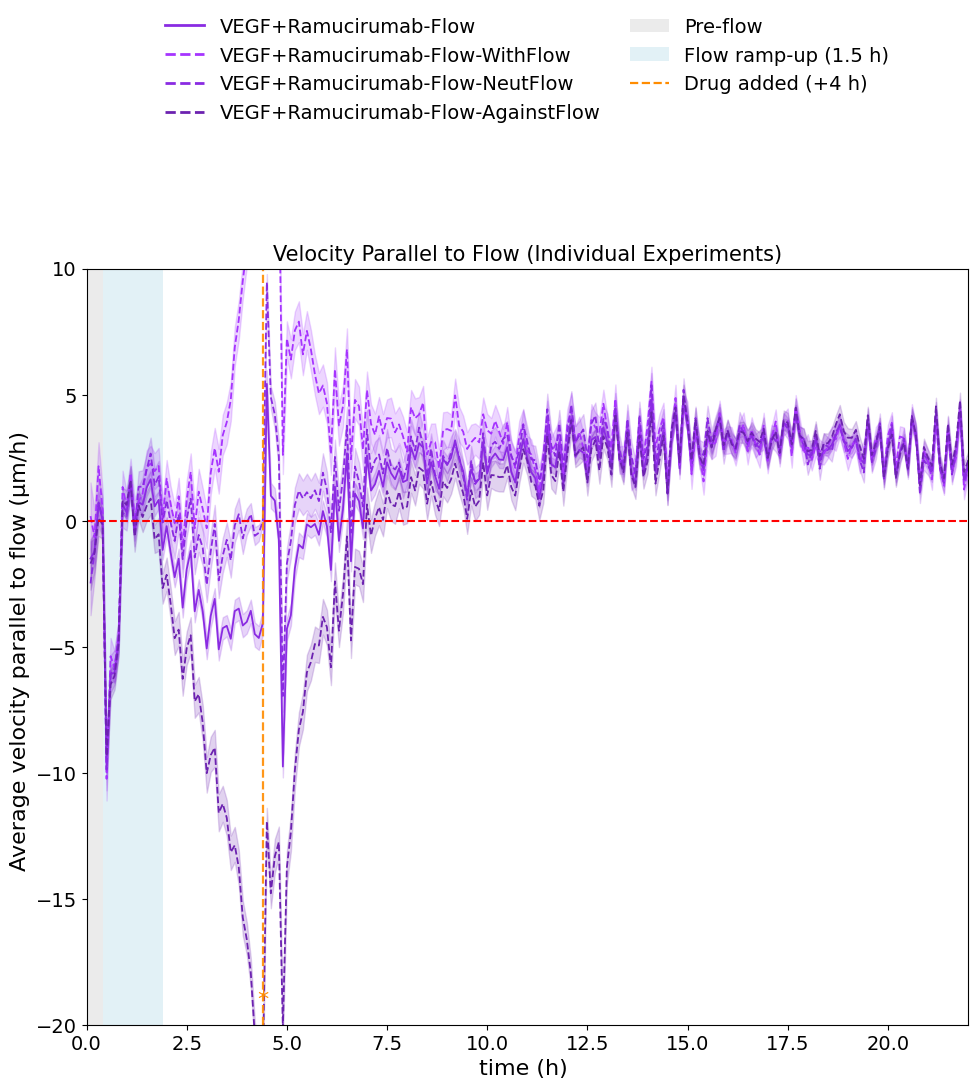

In [39]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'DejaVu Sans',     # default modern sans serif
})

# Legend toggles (set False/True as needed)
show_treatment_legend = bool(parameters.get('show_treatment_legend', True))
show_band_legend = bool(parameters.get('show_band_legend', True))

# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["vel_x_mu_per_h"])
#plot_migration_speeds = migration_speed_df.dropna()
#plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)
# DO NOT filter by FRAME >= interval anymore
#plot_migration_speeds = plot_migration_speeds[plot_migration_speeds["FRAME"] >= interval] --> to be removed
print("plot_migration_speeds", plot_migration_speeds.shape)

#fig, ax = plt.subplots(len(intervals),figsize=(15,30))
fig, ax = plt.subplots(1, figsize=(10,12))

# choose a small cycle of alphas for 1–3 replicates (extend if needed)
alpha_cycle = [1, 0.80, 0.55]   # replicate 1, 2, 3 within *each* treatment
# only plot treatments that actually exist
present_treatments = [t for t in treatment_order
                      if (plot_migration_speeds["treatment"] == t).any()]

# subset-specific line styles: parent solid, subsets dashed
subset_linestyles = {
    "WithFlow": "--",
    "NeutFlow": "--",
    "AgainstFlow": "--",
}

def _subset_linestyle(treatment_name: str):
    for subset_name, linestyle in subset_linestyles.items():
        if treatment_name.endswith(f"-{subset_name}"):
            return linestyle
    return "solid"  # parent (non-subset)
 
for t in present_treatments:
    # boolean mask avoids building a big grouped copy
    m_t = (plot_migration_speeds["treatment"].values == t)
    ls = _subset_linestyle(t)

    # stable order of filenames within this treatment
    files_t = pd.unique(plot_migration_speeds.loc[m_t, "filename"])

    for i, fname in enumerate(files_t):
        a = alpha_cycle[i % len(alpha_cycle)]
        m_tf = m_t & (plot_migration_speeds["filename"].values == fname)

        # slice ONLY the columns needed for plotting to minimize memory
        df_f = plot_migration_speeds.loc[m_tf, ["time_in_h", "vel_x_mu_per_h", "treatment", "filename"]]

        sns.lineplot(x = "time_in_h",
                    y = "vel_x_mu_per_h",
                    hue = "treatment", hue_order = treatment_order, 
                    data = df_f,
                    linestyle=ls,
                    legend=False,   # suppress the built-in mixed legend
                    lw=1.3, alpha=a,
                    ax=ax, errorbar=('ci', 95), palette=color_palette
                    ) 


#sns.lineplot(x = "FRAME", y = "vel_x", hue = "condition", data = plot_migration_speeds, ax=ax, ci = 90) 
#interval_length_min = 5*intervals[i]
#ax.set_title("time interval %s min" % interval_length_min)

ax.set_ylabel("Average velocity parallel to flow (µm/h) ", fontsize=16)
ax.set_xlabel("time (h) ", fontsize=16)

# — tick step (major ticks) —
# x every 2.5 hours:
ax.xaxis.set_major_locator(mticker.MultipleLocator(2.5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))  # 0.0, 2.5, 5.0, ...

ax.set_title("Velocity Parallel to Flow (Individual Experiments)", fontsize=15)
ax.set_xlim(0,22.0)
ax.set_ylim(-20, 10)
ax.axhline(y = 0.0, color = 'r', linestyle = 'dashed')
# Draw pre-flow/ramp + optional drug-addition marker
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

# --- custom legend: independently toggle treatment and flow-stage entries ---
treatment_handles = []
if show_treatment_legend:
    treatment_handles = [
        Line2D([0], [0], color=color_palette[t], lw=2, linestyle=_subset_linestyle(t), label=t)
        for t in treatment_order
    ]

band_handles = []
if show_band_legend and show_pre_flow_band:
    band_handles.append(Patch(facecolor='0.85', edgecolor='none', alpha=0.5, label='Pre-flow'))
    if show_flow_ramp_band and flow_ramp_duration_h > 0:
        band_handles.append(Patch(facecolor=flow_ramp_color, edgecolor='none', alpha=0.35,
                                  label=f'Flow ramp-up ({flow_ramp_duration_h:g} h)'))
    if show_drug_addition_marker and drug_addition_after_flow_h >= 0:
        if drug_marker_style in ('vline', 'both'):
            band_handles.append(Line2D([0], [0], color=drug_marker_color, linestyle='--', lw=1.6,
                                       label=f'Drug added (+{drug_addition_after_flow_h:g} h)'))
        elif drug_marker_style == 'asterisk':
            band_handles.append(Line2D([0], [0], marker='*', color=drug_marker_color, linestyle='None',
                                       markersize=10, label=f'Drug added (+{drug_addition_after_flow_h:g} h)'))

handles = treatment_handles + band_handles

if handles:
    # dynamically compute number of columns
    ncols = 2  # fixed number of entries per row
    nrows = int(np.ceil(len(handles) / ncols))

    ax.legend(handles=handles, title=None,
              loc="lower center", bbox_to_anchor=(0.5, 1.02 + 0.05 * (nrows - 1)),  # bump up if multiple rows,
              ncol=ncols, frameon=False, columnspacing=1.5, handletextpad=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave some room at top for legend

plt.savefig(str(output_folder.joinpath(subfolder, "v_parallel_to_flow_ind_VEGF_perturb_prelim_withsubsets_Ramucirumab" + ".pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "v_parallel_to_flow_ind_VEGF_perturb_prelim_withsubsets_Ramucirumab" + ".png")))

#            plt.savefig(str(output_folder.joinpath(subfolder, "trajectories_" + condition + "_" + row["experimentID"] + ".png"))) , template to help brainstorm on how to improve plot nomenclature 
#           especially for producing combinations with different treatments, or parameters during refactor/troublehshoot/final fig protoytyping 



 velocity against flow grouped by treatment and filename - ALTERNATIVE, old version. Adds way too many filenames on legend

In [ ]:
plt.rcParams.update({'font.size': 14})


# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["vel_x_mu_per_h"])
#plot_migration_speeds = migration_speed_df.dropna()
plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)
# DO NOT filter by FRAME >= interval anymore
#plot_migration_speeds = plot_migration_speeds[plot_migration_speeds["FRAME"] >= interval] --> to be removed
print("plot_migration_speeds", plot_migration_speeds.shape)

#fig, ax = plt.subplots(len(intervals),figsize=(15,30))
fig, ax = plt.subplots(1, figsize=(16,8))

sns.lineplot(x = "time_in_h",
             y = "vel_x_mu_per_h",
             hue = "treatment", hue_order = treatment_order, 
             data = plot_migration_speeds, 
             style="filename",
             ax=ax, errorbar=('ci', 95), palette=color_palette, ) 

#sns.lineplot(x = "FRAME", y = "vel_x", hue = "condition", data = plot_migration_speeds, ax=ax, ci = 90) 
#interval_length_min = 5*intervals[i]
#ax.set_title("time interval %s min" % interval_length_min)
ax.set_ylabel("velocity parallel to flow in microns/h")
ax.set_xlabel("time(h)")
ax.set_title("Average velocity parallel to flow (all individual experiments)")
#ax.set_ylim(-7.0,7.0)
ax.axhline(y = 0.0, color = 'r', linestyle = 'dashed')
# Draw pre-flow band (optional)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)  # bbox_to_anchor: place legend just outside right edge (x=1.05) aligned to top (y=1); loc=2 anchors the legend's upper-left corner at that point; borderaxespad=0 removes extra padding between axes and legend
plt.tight_layout()  # auto-adjust layout so labels and legend fit within the figure
#plt.savefig("velocity_parallel_to_flow_filename_all.pdf")
#plt.savefig("velocity_parallel_to_flow_filename_all.png")
#plt.savefig(str(output_folder.joinpath(subfolder, "v_parallel_to_flow_individual_exps_timelag_4_with_variable_initial_lag" + ".pdf")))
#plt.savefig(str(output_folder.joinpath(subfolder, "v_parallel_to_flow_individual_exps_timelag_4_with_variable_initial_lag" + ".png")))

#            plt.savefig(str(output_folder.joinpath(subfolder, "trajectories_" + condition + "_" + row["experimentID"] + ".png"))) , template to help brainstorm on how to improve plot nomenclature 
#           especially for producing combinations with different treatments, or parameters during refactor/troublehshoot/final fig protoytyping 


# velocity against flow grouped by treatment 

Alternative, old version. Slower, different legend

In [ ]:
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'DejaVu Sans',     # default modern sans serif
    'font.size': 16
})

# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["vel_x_mu_per_h"])
#plot_migration_speeds = migration_speed_df.dropna()
#plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)
# DO NOT filter by FRAME >= interval anymore
#plot_migration_speeds = plot_migration_speeds[plot_migration_speeds["FRAME"] >= interval] --> to be removed


#fig, ax = plt.subplots(len(intervals),figsize=(15,30))
fig, ax = plt.subplots(1, figsize=(13,8))

#sns.lineplot(x = "time_in_h", y = "vel_x_mu_per_h", hue = "condition", data = plot_migration_speeds, ax=ax, ci = 90)
#color_palette = {"siGENOMEsiKank1+lowVEGF-Flow": "limegreen", "siCtrl+highVEGF-Stat": "violet", "siCtrl+highVEGF-Flow": "red"}

if len(treatment_order) > 1: 
    sns.lineplot(x = "time_in_h", y = "vel_x_mu_per_h", hue = "treatment", hue_order = treatment_order, 
             data = plot_migration_speeds, ax=ax, errorbar = errorbar, palette = color_palette) 
else:
    sns.lineplot(x = "time_in_h", y = "vel_x_mu_per_h", hue = "color", hue_order = ["red", "green"],
             data = plot_migration_speeds, ax=ax, errorbar = errorbar, palette=color_palette) 


#sns.lineplot(x = "FRAME", y = "vel_x", hue = "condition", data = plot_migration_speeds, ax=ax, ci = 90) 
#interval_length_min = 5*intervals[i]
#ax.set_title("time interval %s min" % interval_length_min)
ax.set_ylabel("velocity parallel to flow in $\\mu$m/h")
ax.set_ylim(-20.0,10.0)
#plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_xlabel("time in h")
ax.set_title("Average velocity parallel to flow (Grouped Trend of Experiments)")
#ax.set_xlim(0,65)
plt.tight_layout()
ax.axhline(y = 0.0, color = 'r', linestyle = 'dashed')
# Draw pre-flow band (optional)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
#plt.savefig(str(output_folder.joinpath(subfolder, "v_parallel_to_flow_grouped_timelag_4_with_variable_initial_lag" + ".pdf")))
#plt.savefig(str(output_folder.joinpath(subfolder, "v_parallel_to_flow_grouped_timelag_4_with_variable_initial_lag" + ".png")))


New version, bit faster, different legend style

In [28]:
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'DejaVu Sans',     # default modern sans serif
})

# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["vel_x_mu_per_h"])
#plot_migration_speeds = migration_speed_df.dropna()
#plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)
# DO NOT filter by FRAME >= interval anymore
#plot_migration_speeds = plot_migration_speeds[plot_migration_speeds["FRAME"] >= interval] --> to be removed
print("plot_migration_speeds", plot_migration_speeds.shape)

#fig, ax = plt.subplots(len(intervals),figsize=(15,30))
fig, ax = plt.subplots(1, figsize=(10,10))


present_treatments = [t for t in treatment_order
                      if (plot_migration_speeds["treatment"] == t).any()]

for t in present_treatments:
    # filter (small slice) **per treatment**, not per filename
    m_t  = (plot_migration_speeds["treatment"].values == t)
    df_t = plot_migration_speeds.loc[m_t, ["time_in_h", "vel_x_mu_per_h", "treatment"]]

    sns.lineplot(
        data=df_t,
        x="time_in_h", y="vel_x_mu_per_h",
        hue="treatment", hue_order=treatment_order, palette=color_palette,
        errorbar=("ci", 95),         # 95% CI across those observations
        lw=2, alpha=0.9,
        legend=False, ax=ax
    )


# labels & ticks
ax.set_ylabel("Average velocity parallel to flow (µm/h)", fontsize=16)
ax.set_xlabel("time (h)", fontsize=16)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2.5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# title & axes decorations
ax.set_title("Average Velocity Parallel to Flow (Pooled Experiments)", fontsize=15)
ax.set_xlim(0, 20.0)
ax.axhline(y=0.0, color='r', linestyle='dashed')
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

# --- custom legend: treatments only, above x-axis ---
handles = [Line2D([0],[0], color=color_palette[t], lw=2, label=t) for t in treatment_order]

ncols = 2                                   # two entries per row
nrows = int(np.ceil(len(treatment_order)/ncols))
y_offset = -0.22 - 0.05*(nrows - 1)         # push further down for extra rows

ax.legend(handles=handles, title=None,
          loc="lower center", bbox_to_anchor=(0.5, 1.02 + 0.05 * (nrows - 1)),  # bump up if multiple rows,
          ncol=ncols, frameon=False, columnspacing=1.5, handletextpad=0.8)

# leave extra bottom margin for the legend (grow with rows)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave some room at top for legend

plt.savefig(str(output_folder.joinpath(subfolder, "v_parallel_to_flow_grouped_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "v_parallel_to_flow_grouped_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".png")))

#            plt.savefig(str(output_folder.joinpath(subfolder, "trajectories_" + condition + "_" + row["experimentID"] + ".png"))) , template to help brainstorm on how to improve plot nomenclature 
#           especially for producing combinations with different treatments, or parameters during refactor/troublehshoot/final fig protoytyping 


KeyboardInterrupt: 

# Total Velocity

Total Velocity (all individual experiments, rolling 1-hour window)

plot_tot_1h shape: (24227009, 31)


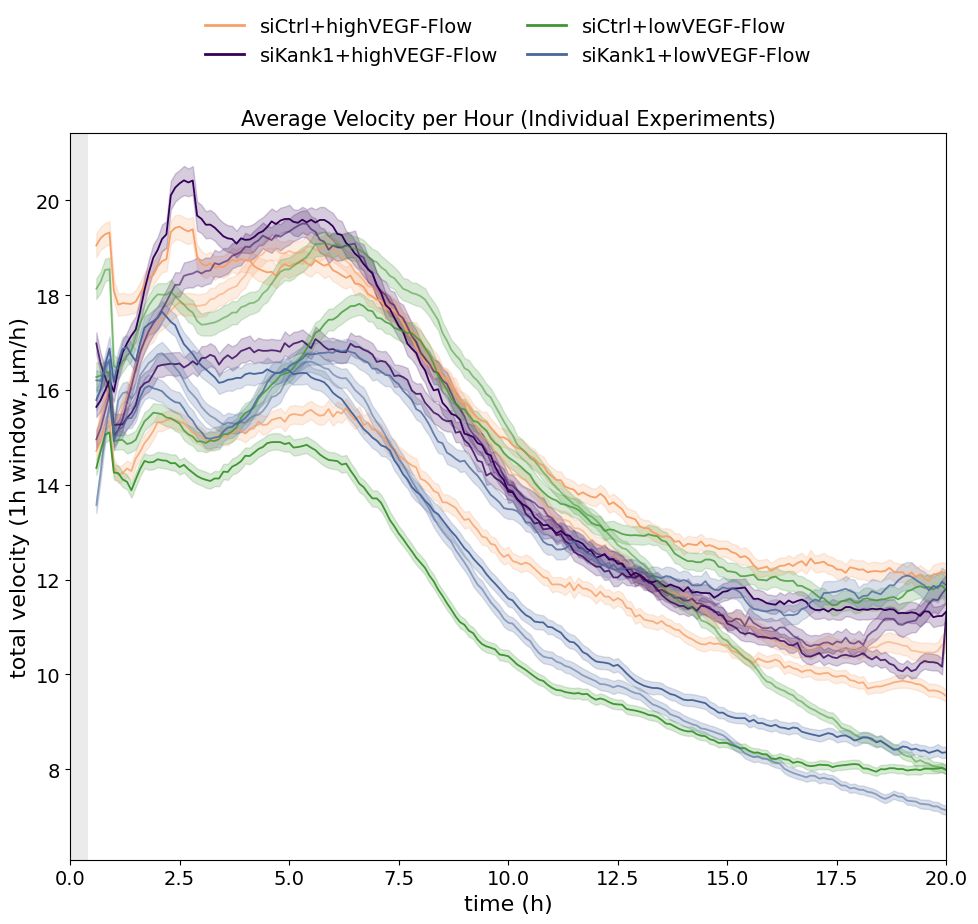

In [16]:
plot_tot_1h = migration_speed_df.dropna(subset=["tot_vel_1h_mu_per_h"])
print("plot_tot_1h shape:", plot_tot_1h.shape)

fig, ax = plt.subplots(1, figsize=(10,10))

# choose a small cycle of alphas for 1–3 replicates (extend if needed)
alpha_cycle = [1, 0.80, 0.55]   # replicate 1, 2, 3 within *each* treatment
# only plot treatments that actually exist
present_treatments = [t for t in treatment_order
                      if (plot_migration_speeds["treatment"] == t).any()]

for t in present_treatments:
    # boolean mask avoids building a big grouped copy
    m_t = (plot_migration_speeds["treatment"].values == t)

    # stable order of filenames within this treatment
    files_t = pd.unique(plot_migration_speeds.loc[m_t, "filename"])

    for i, fname in enumerate(files_t):
        a = alpha_cycle[i % len(alpha_cycle)]
        m_tf = m_t & (plot_migration_speeds["filename"].values == fname)

        # slice ONLY the columns needed for plotting to minimize memory
        df_f = plot_migration_speeds.loc[m_tf, ["time_in_h", "tot_vel_1h_mu_per_h", "treatment", "filename"]]


        sns.lineplot(x = "time_in_h",
                    y = "tot_vel_1h_mu_per_h",
                    hue = "treatment", hue_order = treatment_order, 
                    data = df_f, 
                    style="filename",
                    dashes=False,
                    legend=False,   # suppress the built-in mixed legend
                    lw=1.3, alpha=a,
                    ax=ax, errorbar=('ci', 95), palette=color_palette 
                    ) 

ax.set_xlim(0, 20.0)
ax.set_ylabel("total velocity (1h window, μm/h)", fontsize=16)
ax.set_xlabel("time (h)", fontsize=16)
ax.set_title("Average Velocity per Hour (Individual Experiments)", fontsize=15)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

ax.legend(handles=handles, title=None,
          loc="lower center", bbox_to_anchor=(0.5, 1.02 + 0.05 * (nrows - 1)),  # bump up if multiple rows,
          ncol=ncols, frameon=False, columnspacing=1.5, handletextpad=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave some room at top for legend

plt.savefig(str(output_folder.joinpath(subfolder, "tot_speed_1h_individual_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "tot_speed_1h_individual_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".png")))


Total Velocity (ALTERNATIVE- different legend, Grouped experiments, rolling 1-hour window)

In [ ]:
plot_migration_speeds = migration_speed_df.dropna(subset=["vel_mu_per_h"])

#plot_migration_speeds = plot_migration_speeds.iloc[::subsampling_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)

plt.rcParams.update({'font.size': 14})

#fig, ax = plt.subplots(len(intervals),figsize=(15,30))
fig, ax = plt.subplots(1, figsize=(8,8))

#sns.lineplot(x = "time_in_h", y = "vel_x_mu_per_h", hue = "condition", data = plot_migration_speeds, ax=ax, ci = 90)

# sns.lineplot(x = "time_in_h", y = "vel_mu_per_h", hue = "condition", 
#              hue_order = hue_order, data = plot_migration_speeds, ax=ax, errorbar = errorbar) 
if len(treatment_order) > 1: 
    sns.lineplot(x = "time_in_h", y = "vel_mu_per_h", hue = "treatment", hue_order = treatment_order, 
            data = plot_migration_speeds, ax=ax, errorbar = errorbar, palette = color_palette)
else:            
    sns.lineplot(x = "time_in_h", y = "vel_mu_per_h",  hue = "color", hue_order = ["green", "red"],
            data = plot_migration_speeds, ax=ax, errorbar = errorbar, palette = color_palette) 


#sns.lineplot(x = "FRAME", y = "vel_x", hue = "condition", data = plot_migration_speeds, ax=ax, ci = 90) 
#interval_length_min = 5*intervals[i]
#ax.set_title("time interval %s min" % interval_length_min)
ax.set_ylabel("velocity in microns/h")
ax.set_xlabel("time in h")
ax.set_ylim(0.0,30.0)
ax.set_title("Total average velocity (Grouped Trend of Experiments)")
#plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
#plt.tight_layout()

# Draw pre-flow band (optional)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

plt.savefig(str(output_folder.joinpath(subfolder, "total_velocity_grouped_timelag_4_with_variable_initial_lag" + ".pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "total_velocity_grouped_timelag_4_with_variable_initial_lag" + ".png")))

#plt.savefig("velocity_%s.pdf" % condition)
#plt.savefig("velocity_%s.png" % condition)

Total Velocity (Grouped trend of experiments, rolling 1-hour window)

plot_migration_speeds (25152069, 31)


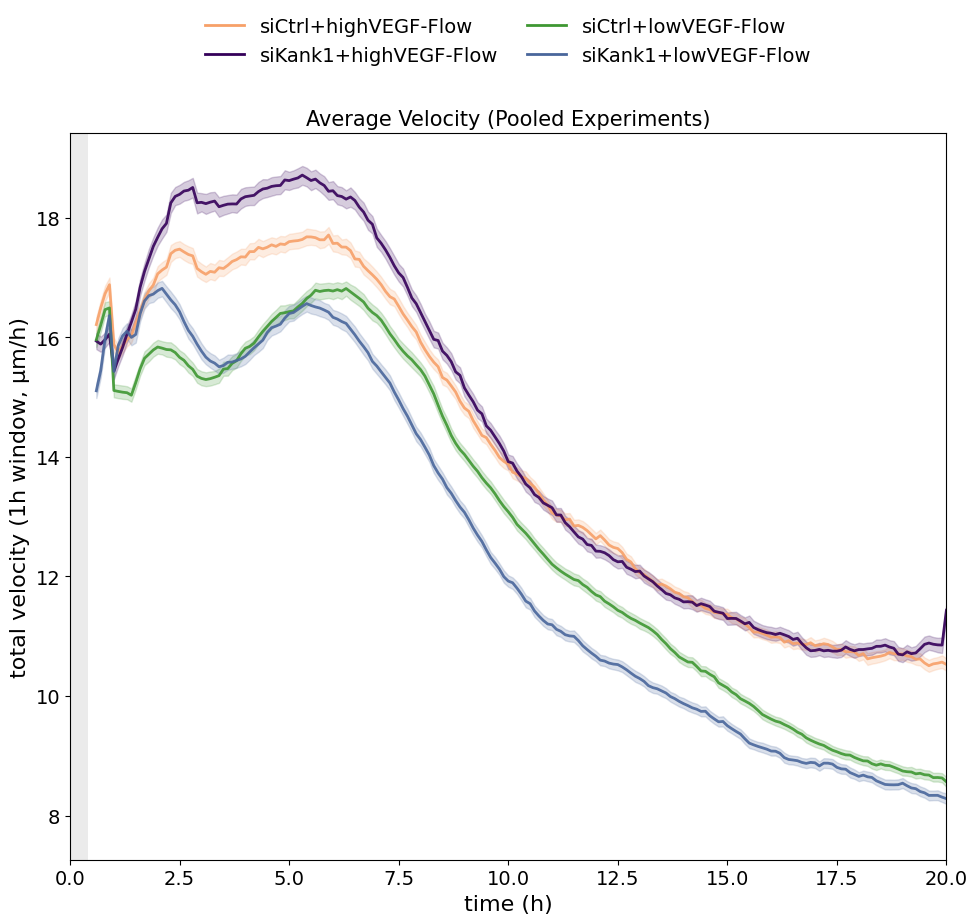

In [17]:
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'DejaVu Sans',     # default modern sans serif
})

# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["vel_x_mu_per_h"])
#plot_migration_speeds = migration_speed_df.dropna()
#plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)
# DO NOT filter by FRAME >= interval anymore
#plot_migration_speeds = plot_migration_speeds[plot_migration_speeds["FRAME"] >= interval] --> to be removed
print("plot_migration_speeds", plot_migration_speeds.shape)

#fig, ax = plt.subplots(len(intervals),figsize=(15,30))
fig, ax = plt.subplots(1, figsize=(10,10))


present_treatments = [t for t in treatment_order
                      if (plot_migration_speeds["treatment"] == t).any()]

for t in present_treatments:
    # filter (small slice) **per treatment**, not per filename
    m_t  = (plot_migration_speeds["treatment"].values == t)
    df_t = plot_migration_speeds.loc[m_t, ["time_in_h", "tot_vel_1h_mu_per_h", "treatment"]]

    sns.lineplot(
        data=df_t,
        x="time_in_h", y="tot_vel_1h_mu_per_h",
        hue="treatment", hue_order=treatment_order, palette=color_palette,
        errorbar=("ci", 95),         # 95% CI across those observations
        lw=2, alpha=0.9,
        legend=False, ax=ax
    )



# labels & ticks
ax.set_ylabel("total velocity (1h window, μm/h)", fontsize=16)
ax.set_xlabel("time (h)", fontsize=16)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2.5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# title & axes decorations
ax.set_title("Average Velocity (Pooled Experiments)", fontsize=15)
ax.set_xlim(0, 20.0)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

# --- custom legend: treatments only, above x-axis ---
handles = [Line2D([0],[0], color=color_palette[t], lw=2, label=t) for t in treatment_order]

ncols = 2                                   # two entries per row
nrows = int(np.ceil(len(treatment_order)/ncols))
ax.legend(handles=handles, title=None,
          loc="lower center", bbox_to_anchor=(0.5, 1.02 + 0.05 * (nrows - 1)),  # bump up if multiple rows,
          ncol=ncols, frameon=False, columnspacing=1.5, handletextpad=0.8)

# leave extra bottom margin for the legend (grow with rows)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave some room at top for legend


plt.savefig(str(output_folder.joinpath(subfolder, "tot_speed_1h_grouped_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "tot_speed_1h_grouped_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".png")))

#            plt.savefig(str(output_folder.joinpath(subfolder, "trajectories_" + condition + "_" + row["experimentID"] + ".png"))) , template to help brainstorm on how to improve plot nomenclature 
#           especially for producing combinations with different treatments, or parameters during refactor/troublehshoot/final fig protoytyping 


In [ ]:
#similar to the one as above, but with incorrect nomenclature and arbitrary y=0 line that will never be reached. for some reason the savefig is titled "filtered", not sure why

plt.rcParams.update({'font.size': 14})

plot_migration_speeds = migration_speed_df.dropna()
plot_migration_speeds = plot_migration_speeds[plot_migration_speeds["FRAME"] >= interval]



#fig, ax = plt.subplots(len(intervals),figsize=(15,30))
fig, ax = plt.subplots(1, figsize=(16,8))

sns.lineplot(x = "time_in_h", y = "vel_mu_per_h", hue = "treatment", hue_order = treatment_order, 
             data = plot_migration_speeds, style="filename", ax=ax, errorbar = errorbar) 

#sns.lineplot(x = "FRAME", y = "vel_x", hue = "condition", data = plot_migration_speeds, ax=ax, ci = 90) 
#interval_length_min = 5*intervals[i]
#ax.set_title("time interval %s min" % interval_length_min)
ax.set_title("Total average velocity (Grouped Trend of Experiments)")
ax.set_ylabel("velocity in microns/h")
ax.set_ylim(-30.0,30.0)
ax.axhline(y = 0.0, color = 'r', linestyle = 'dashed')
# Draw pre-flow band (optional)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig("velocity_filename_filtered.pdf")
plt.savefig("velocity_filename_filtered.png")

# Velocity Perpendicular to Flow


Old version

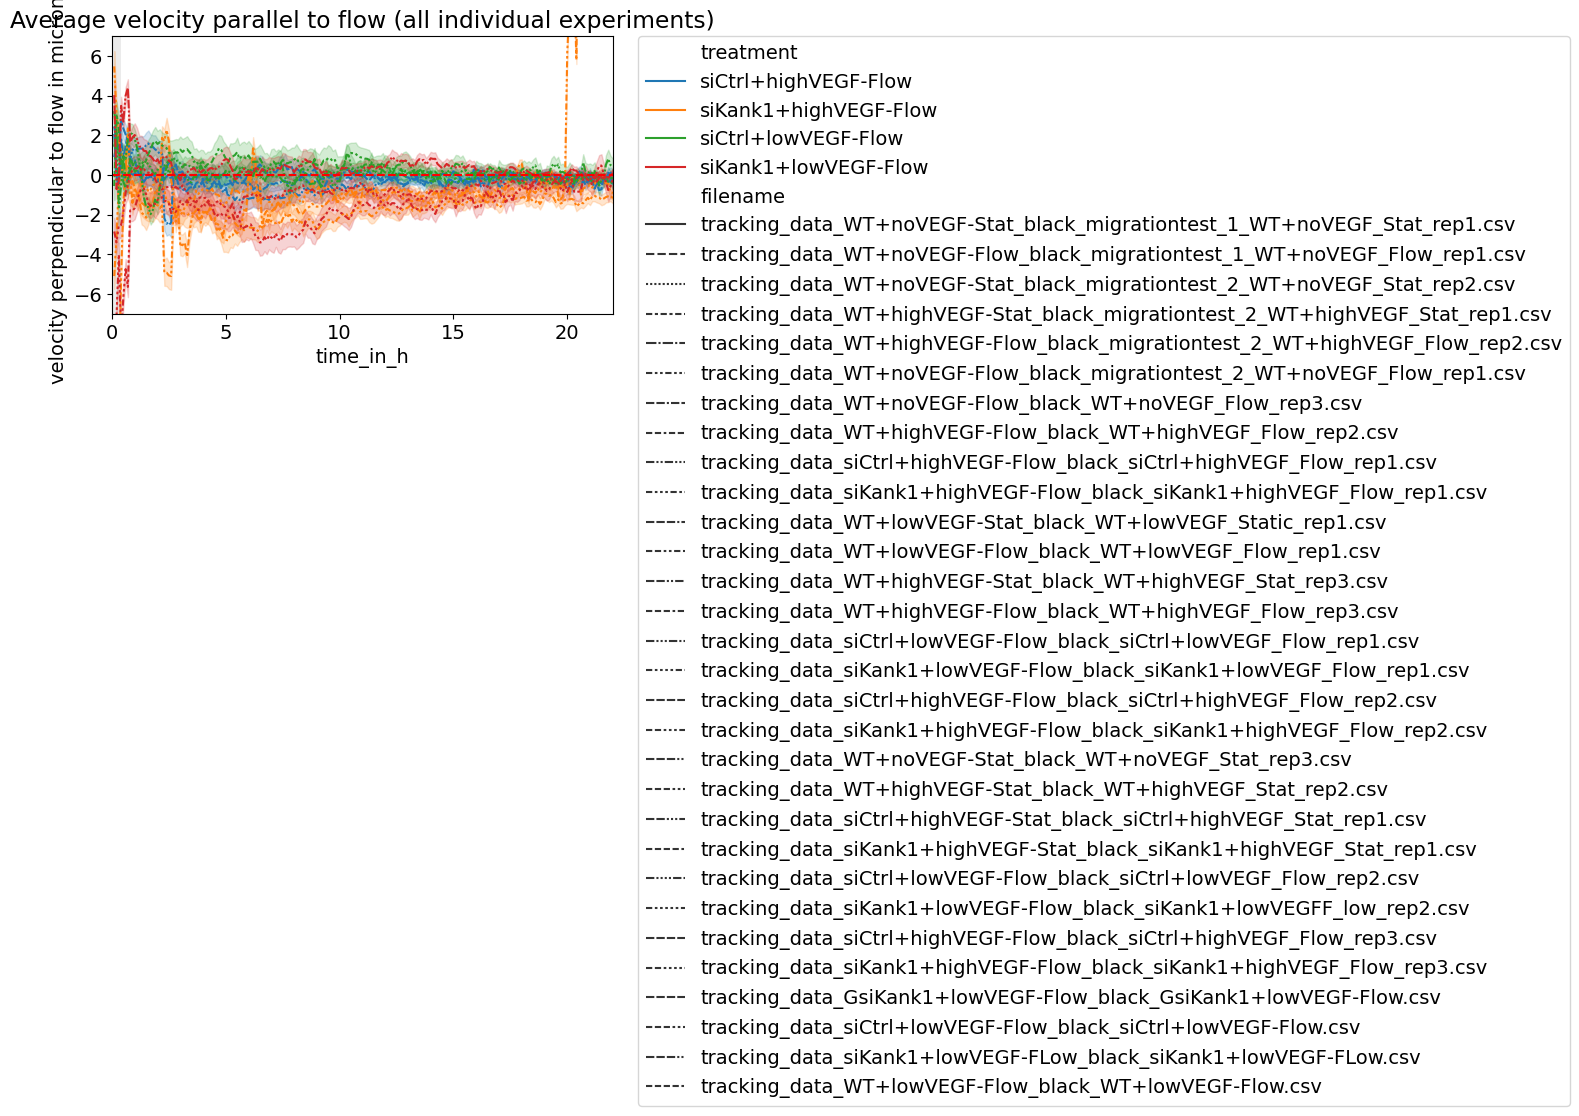

In [27]:
plot_migration_speeds = migration_speed_df.dropna(subset=["vel_y_mu_per_h"])


#fig, ax = plt.subplots(len(intervals),figsize=(15,30))
fig, ax = plt.subplots(1, figsize=(16,8))

sns.lineplot(x = "time_in_h", y = "vel_y_mu_per_h", hue = "treatment", hue_order = treatment_order, 
             data = plot_migration_speeds, style="filename", ax=ax, errorbar = errorbar) 

#sns.lineplot(x = "FRAME", y = "vel_x", hue = "condition", data = plot_migration_speeds, ax=ax, ci = 90) 
#interval_length_min = 5*intervals[i]
#ax.set_title("time interval %s min" % interval_length_min)
ax.set_ylabel("velocity perpendicular to flow in microns/h")
ax.set_ylim(-7.0,7.0)
ax.set_xlim(0, 22.0)
ax.set_title("Average velocity parallel to flow (all individual experiments)")
ax.axhline(y = 0.0, color = 'r', linestyle = 'dashed')
# Draw pre-flow band (optional)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()

plt.savefig(str(output_folder.joinpath(subfolder, "vel_perpendicular_grouped_sictrl+sikank1_lowvegf+highvegf_flow" + ".pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "vel_perpendicular_grouped_sictrl+sikank1_lowvegf+highvegf_flow" + ".png")))

New version, different legend, grouped exps


plot_migration_speeds (25152069, 31)


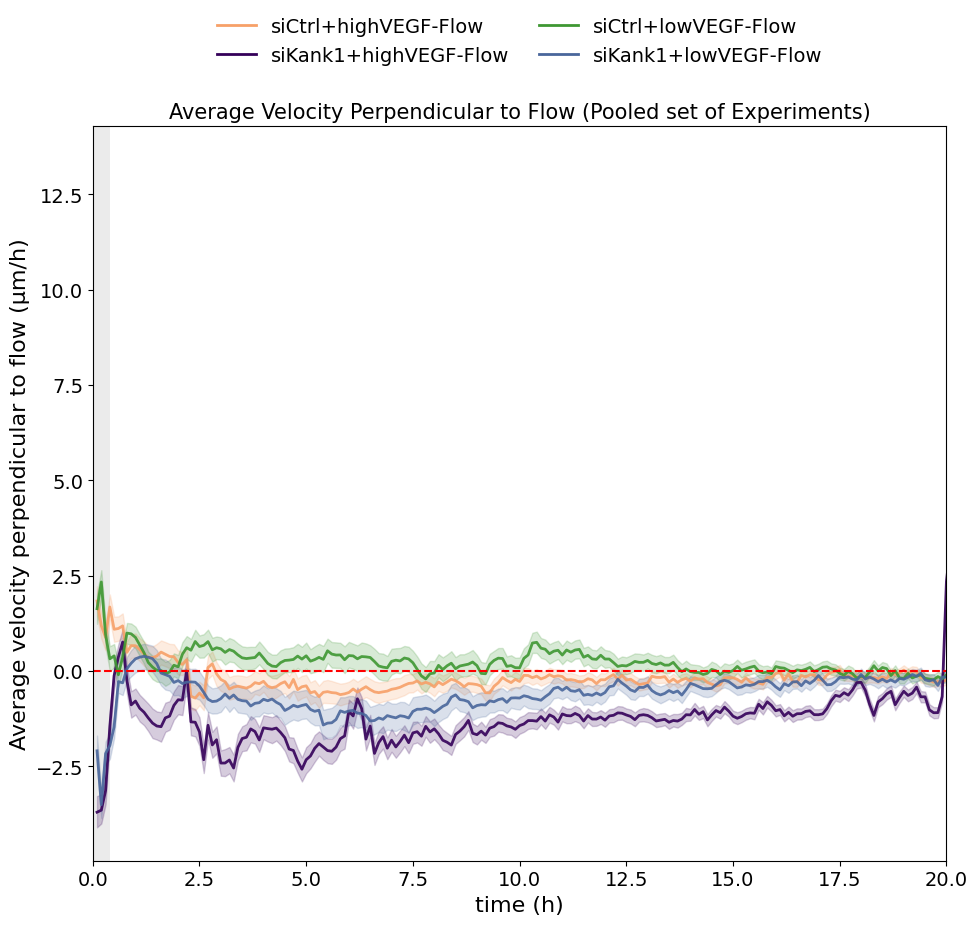

In [ ]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',     # default modern sans serif
})

# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["vel_y_mu_per_h"])
#plot_migration_speeds = migration_speed_df.dropna()
#plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)

print("plot_migration_speeds", plot_migration_speeds.shape)
fig, ax = plt.subplots(1, figsize=(10,10))

present_treatments = [t for t in treatment_order
                      if (plot_migration_speeds["treatment"] == t).any()]

for t in present_treatments:
    # filter (small slice) **per treatment**, not per filename
    m_t  = (plot_migration_speeds["treatment"].values == t)
    df_t = plot_migration_speeds.loc[m_t, ["time_in_h", "vel_y_mu_per_h", "treatment"]]

    sns.lineplot(
        data=df_t,
        x="time_in_h", y="vel_y_mu_per_h",
        hue="treatment", hue_order=treatment_order, palette=color_palette,
        errorbar=("ci", 95),         # 95% CI across those observations
        lw=2, alpha=0.9,
        legend=False, ax=ax
    )


# labels & ticks
ax.set_ylabel("Average velocity perpendicular to flow (µm/h)", fontsize=16)
ax.set_xlabel("time (h)", fontsize=16)
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2.5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# title & axes decorations
ax.set_title("Average Velocity Perpendicular to Flow (Pooled set of Experiments)", fontsize=15)
ax.set_xlim(0, 20.0)
ax.axhline(y=0.0, color='r', linestyle='dashed')
# Draw pre-flow band (optional)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

# --- custom legend: treatments only, above x-axis ---
handles = [Line2D([0],[0], color=color_palette[t], lw=2, label=t) for t in treatment_order]

ncols = 2                                   # two entries per row
nrows = int(np.ceil(len(treatment_order)/ncols))
y_offset = -0.22 - 0.05*(nrows - 1)         # push further down for extra rows

ax.legend(handles=handles, title=None,
          loc="lower center", bbox_to_anchor=(0.5, 1.01 + 0.05 * (nrows - 1)),  # bump up if multiple rows,
          ncol=ncols, frameon=False, columnspacing=1.5, handletextpad=0.8, fontsize=16)

# leave extra bottom margin for the legend (grow with rows)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave some room at top for legend

plt.savefig(str(output_folder.joinpath(subfolder, "vel_perpendicular_grouped_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "vel_perpendicular_grouped_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".png")))


# Effective Velocity(1 hour window)

Effective Velocity Parallel to Flow, 1-hour window (New version, different legend, individual experiments)

plot_migration_speeds (13871930, 31)


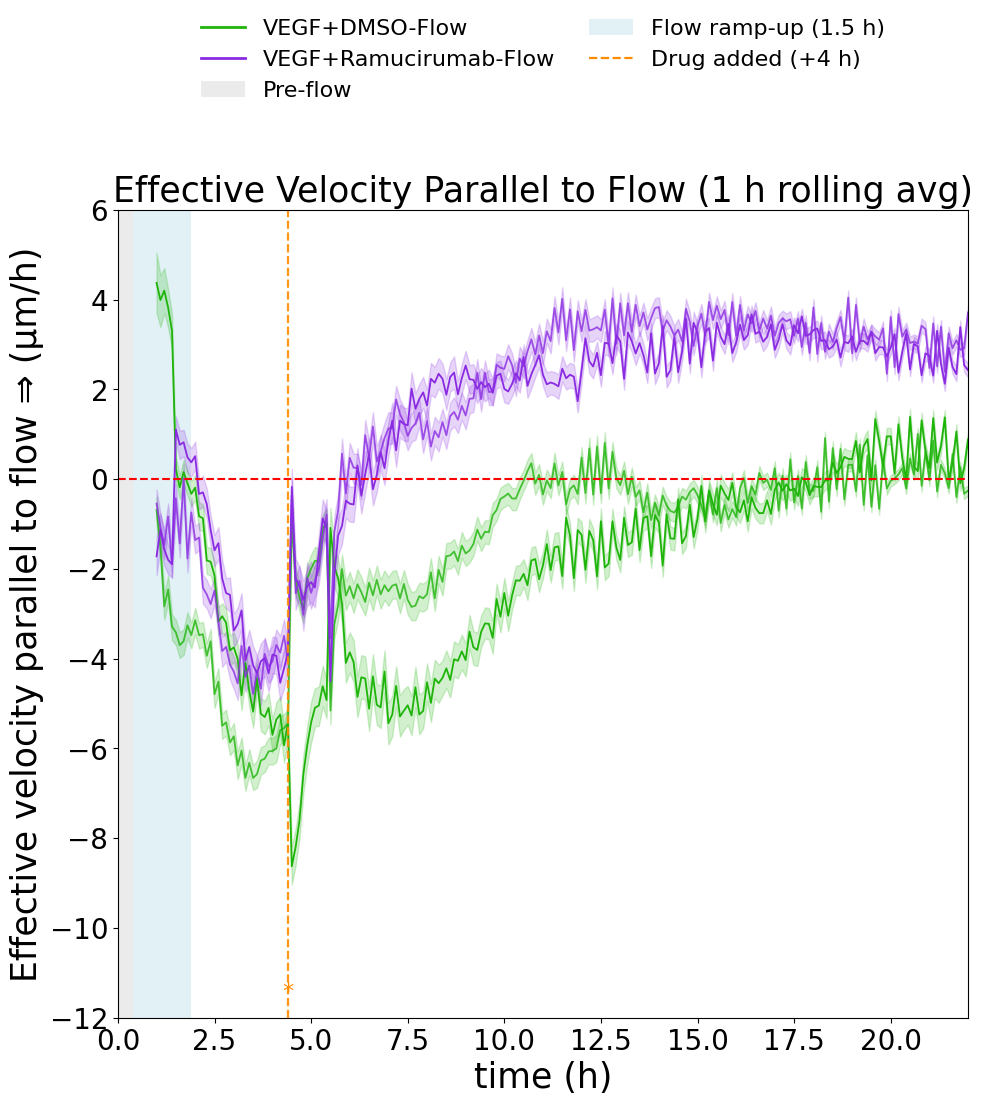

In [14]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'DejaVu Sans',     # default modern sans serif
})

# Legend toggles (set False/True as needed)
show_treatment_legend = bool(parameters.get('show_treatment_legend', True))
show_band_legend = bool(parameters.get('show_band_legend', True))

# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["eff_vel_1h_x_mu_per_h"])
#plot_migration_speeds = migration_speed_df.dropna()
#plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)

print("plot_migration_speeds", plot_migration_speeds.shape)
fig, ax = plt.subplots(1, figsize=(10,12))

# choose a small cycle of alphas for 1–3 replicates (extend if needed)
alpha_cycle = [1, 0.80, 0.55]   # replicate 1, 2, 3 within *each* treatment
# only plot treatments that actually exist
present_treatments = [t for t in treatment_order
                      if (plot_migration_speeds["treatment"] == t).any()]

# subset-specific line styles: parent solid, subsets dashed
subset_linestyles = {
    "WithFlow": "--",
    "NeutFlow": "--",
    "AgainstFlow": "--",
}

def _subset_linestyle(treatment_name: str):
    for subset_name, linestyle in subset_linestyles.items():
        if treatment_name.endswith(f"-{subset_name}"):
            return linestyle
    return "solid"  # parent (non-subset)

for t in present_treatments:
    # boolean mask avoids building a big grouped copy
    m_t = (plot_migration_speeds["treatment"].values == t)
    ls = _subset_linestyle(t)

    # stable order of filenames within this treatment
    files_t = pd.unique(plot_migration_speeds.loc[m_t, "filename"])

    for i, fname in enumerate(files_t):
        a = alpha_cycle[i % len(alpha_cycle)]
        m_tf = m_t & (plot_migration_speeds["filename"].values == fname)

        # slice ONLY the columns needed for plotting to minimize memory
        df_f = plot_migration_speeds.loc[m_tf, ["time_in_h", "eff_vel_1h_x_mu_per_h", "treatment", "filename"]]

        sns.lineplot(x = "time_in_h",
                    y = "eff_vel_1h_x_mu_per_h",
                    hue = "treatment", hue_order = treatment_order,
                    data = df_f,
                    linestyle=ls,
                    legend=False,   # suppress the built-in mixed legend
                    lw=1.3, alpha=a,
                    ax=ax, errorbar=('ci', 95), palette=color_palette
                    )

# labels & ticks
ax.set_ylabel("Effective velocity parallel to flow ⇒ (µm/h)", fontsize=25)
ax.set_xlabel("time (h)", fontsize=25)
ax.tick_params(axis='x', labelsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2.5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# title & axes decorations
ax.set_title("Effective Velocity Parallel to Flow (1 h rolling avg)", fontsize=25)
ax.set_xlim(0, 22.0)
ax.set_ylim(-12.0, 6.0)
ax.axhline(y=0.0, color='r', linestyle='dashed')

# Draw pre-flow/ramp + optional drug-addition marker
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

# --- custom legend: independently toggle treatment and flow-stage entries ---
treatment_handles = []
if show_treatment_legend:
    treatment_handles = [
        Line2D([0], [0], color=color_palette[t], lw=2, linestyle=_subset_linestyle(t), label=t)
        for t in treatment_order
    ]

band_handles = []
if show_band_legend and show_pre_flow_band:
    band_handles.append(Patch(facecolor='0.85', edgecolor='none', alpha=0.5, label='Pre-flow'))
    if show_flow_ramp_band and flow_ramp_duration_h > 0:
        band_handles.append(Patch(facecolor=flow_ramp_color, edgecolor='none', alpha=0.35,
                                  label=f'Flow ramp-up ({flow_ramp_duration_h:g} h)'))
    if show_drug_addition_marker and drug_addition_after_flow_h >= 0:
        if drug_marker_style in ('vline', 'both'):
            band_handles.append(Line2D([0], [0], color=drug_marker_color, linestyle='--', lw=1.6,
                                       label=f'Drug added (+{drug_addition_after_flow_h:g} h)'))
        elif drug_marker_style == 'asterisk':
            band_handles.append(Line2D([0], [0], marker='*', color=drug_marker_color, linestyle='None',
                                       markersize=10, label=f'Drug added (+{drug_addition_after_flow_h:g} h)'))

handles = treatment_handles + band_handles

if handles:
    ncols = 2
    nrows = int(np.ceil(len(handles) / ncols))

    ax.legend(handles=handles, title=None,
              loc="lower center", bbox_to_anchor=(0.5, 1.01 + 0.05 * (nrows - 1)),
              ncol=ncols, frameon=False, columnspacing=1.5, handletextpad=0.8, fontsize=16)

# leave extra top margin for the legend
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(str(output_folder.joinpath(subfolder, "eff_speed_1h_parallel_individual_exps_VEGF_vs_Ramucirumab_poster.pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "eff_speed_1h_parallel_individual_exps_VEGF_vs_Ramucirumab_poster.png")))

Effective Velocity Parallel to Flow, 1-hour window (New version, different legend, grouped experiments)

plot_migration_speeds (19230939, 31)


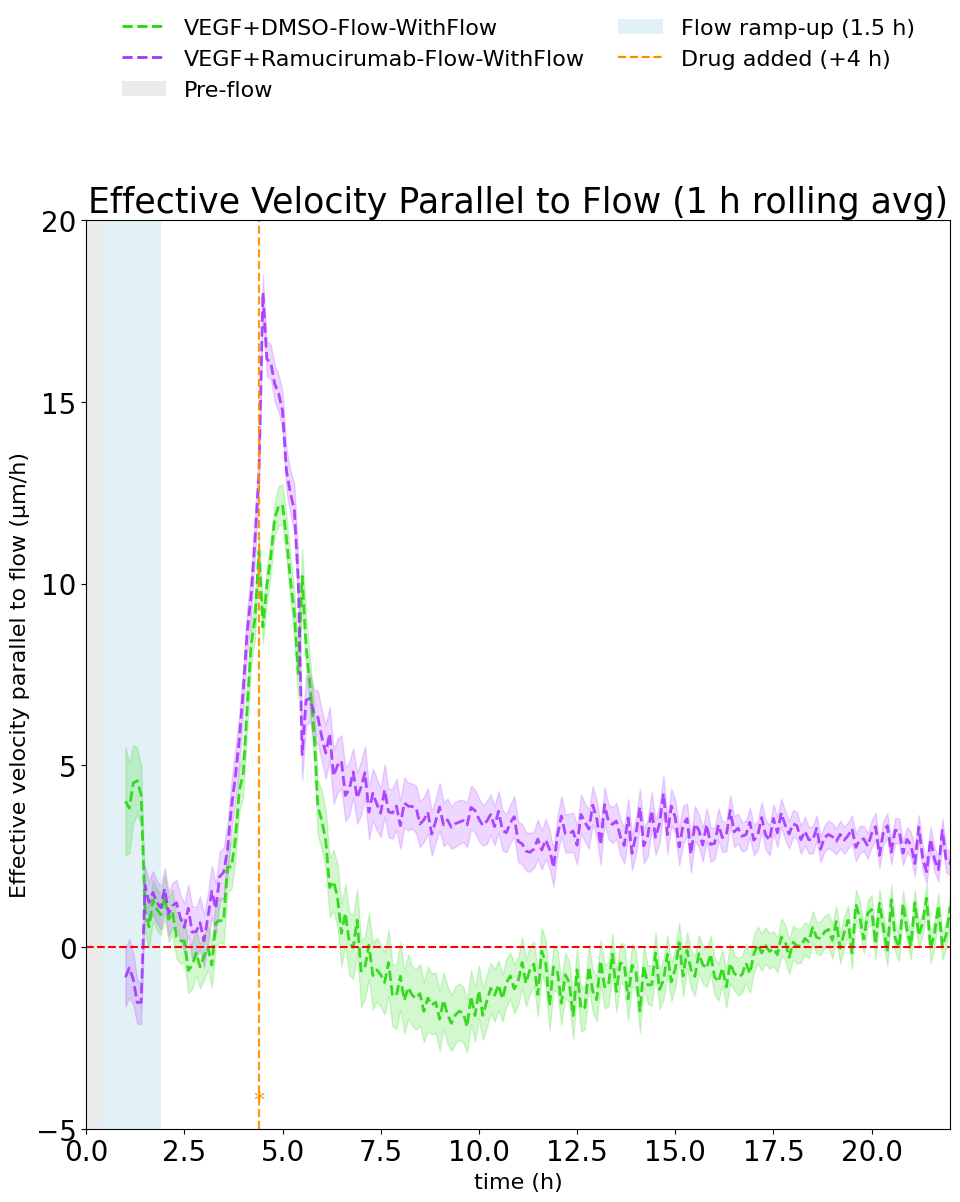

In [46]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',     # default modern sans serif
})

# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["eff_vel_1h_x_mu_per_h"])
#plot_migration_speeds = migration_speed_df.dropna()
#plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)

# Legend toggles (set False/True as needed)
show_treatment_legend = bool(parameters.get('show_treatment_legend', True))
show_band_legend = bool(parameters.get('show_band_legend', True))

print("plot_migration_speeds", plot_migration_speeds.shape)
fig, ax = plt.subplots(1, figsize=(10,13))

# subset-specific line styles: parent solid, subsets dashed
subset_linestyles = {
    "WithFlow": "--",
    "NeutFlow": "--",
    "AgainstFlow": "--",
}

def _subset_linestyle(treatment_name: str):
    for subset_name, linestyle in subset_linestyles.items():
        if treatment_name.endswith(f"-{subset_name}"):
            return linestyle
    return "solid"  # parent (non-subset)

present_treatments = [t for t in treatment_order
                      if (plot_migration_speeds["treatment"] == t).any()]

for t in present_treatments:
    # filter (small slice) **per treatment**, not per filename
    m_t  = (plot_migration_speeds["treatment"].values == t)
    df_t = plot_migration_speeds.loc[m_t, ["time_in_h", "eff_vel_1h_x_mu_per_h", "treatment"]]
    ls = _subset_linestyle(t)

    sns.lineplot(
        data=df_t,
        x="time_in_h", y="eff_vel_1h_x_mu_per_h",
        hue="treatment", hue_order=treatment_order, palette=color_palette,
        linestyle=ls,
        errorbar=("ci", 95),         # 95% CI across those observations
        lw=2, alpha=0.9,
        legend=False, ax=ax
    )


# labels & ticks
ax.set_ylabel("Effective velocity parallel to flow (µm/h)", fontsize=16)
ax.set_xlabel("time (h)", fontsize=16)
ax.tick_params(axis='both', labelsize=20)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2.5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# title & axes decorations

ax.set_title("Effective Velocity Parallel to Flow (1 h rolling avg)", fontsize=25)
ax.set_xlim(0, 22.0)
ax.set_ylim(-5.0, 20.0)
ax.axhline(y=0.0, color='r', linestyle='dashed')
# Draw pre-flow band (optional)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

band_handles = []
if show_band_legend and show_pre_flow_band:
    band_handles.append(Patch(facecolor='0.85', edgecolor='none', alpha=0.5, label='Pre-flow'))
    if show_flow_ramp_band and flow_ramp_duration_h > 0:
        band_handles.append(Patch(facecolor=flow_ramp_color, edgecolor='none', alpha=0.35,
                                  label=f'Flow ramp-up ({flow_ramp_duration_h:g} h)'))
    if show_drug_addition_marker and drug_addition_after_flow_h >= 0:
        if drug_marker_style in ('vline', 'both'):
            band_handles.append(Line2D([0], [0], color=drug_marker_color, linestyle='--', lw=1.6,
                                       label=f'Drug added (+{drug_addition_after_flow_h:g} h)'))
        elif drug_marker_style == 'asterisk':
            band_handles.append(Line2D([0], [0], marker='*', color=drug_marker_color, linestyle='None',
                                       markersize=10, label=f'Drug added (+{drug_addition_after_flow_h:g} h)'))

# --- custom legend: treatments + flow-stage entries ---
treatment_handles = []
if show_treatment_legend:
    treatment_handles = [
        Line2D([0], [0], color=color_palette[t], lw=2, linestyle=_subset_linestyle(t), label=t)
        for t in treatment_order
    ]

handles = treatment_handles + band_handles

if handles:
    ncols = 2
    nrows = int(np.ceil(len(handles) / ncols))

    ax.legend(handles=handles, title=None,
              loc="lower center", bbox_to_anchor=(0.5, 1.01 + 0.05 * (nrows - 1)),
              ncol=ncols, frameon=False, columnspacing=1.5, handletextpad=0.8, fontsize=16)

# leave extra bottom margin for the legend (grow with rows)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave some room at top for legend
plt.savefig(str(output_folder.joinpath(subfolder, "eff_speed_1h_parallel_grouped_exps_Ramu_vsdmso_withflow" + ".pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "eff_speed_1h_parallel_grouped_exps_Ramu_vsdmso_withflow" + ".png")))

Effective Velocity parallel to flow(Old version, individual experiments, 1-hour window)

In [ ]:
plt.rcParams.update({'font.size': 14})
plot_eff_1h_x = migration_speed_df.dropna(subset=["eff_vel_1h_x_mu_per_h"])
print("plot_eff_1h_x shape:", plot_eff_1h_x.shape)

fig, ax = plt.subplots(1, figsize=(16,8))
sns.lineplot(
    x="time_in_h", y="eff_vel_1h_x_mu_per_h",
    hue="treatment", hue_order=treatment_order,
    style="filename",
    data=plot_eff_1h_x, errorbar=('ci', 95),
    palette=color_palette, ax=ax
)
ax.set_ylabel("effective speed ∥ flow (1h, μm/h)")
ax.set_xlabel("time (h)")
ax.set_title("Effective speed parallel to flow (1h window)")
ax.axhline(y=0.0, color='r', linestyle='dashed')
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig(str(output_folder.joinpath(subfolder, f"eff_speed_1h_parallel_individual_exps_timelag_{interval}.pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, f"eff_speed_1h_parallel_individual_exps_timelag_{interval}.png")))


Effective Velocity paperpendicular to flow(individual experiments, 1-hour window)

In [ ]:
plot_eff_1h_y = migration_speed_df.dropna(subset=["eff_vel_1h_y_mu_per_h"])
print("plot_eff_1h_y shape:", plot_eff_1h_y.shape)

fig, ax = plt.subplots(1, figsize=(16,8))
sns.lineplot(
    x="time_in_h", y="eff_vel_1h_y_mu_per_h",
    hue="treatment", hue_order=treatment_order,
    style="filename",
    data=plot_eff_1h_y, errorbar=('ci', 95),
    palette=color_palette, ax=ax
)
ax.set_ylabel("effective speed ⟂ flow (1h, μm/h)")
ax.set_xlabel("time (h)")
ax.set_title("Effective speed perpendicular to flow (1h window)")
ax.axhline(y=0.0, color='r', linestyle='dashed')
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig(str(output_folder.joinpath(subfolder, f"eff_speed_1h_perp_individual_exps_timelag_{interval}.pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, f"eff_speed_1h_perp_individual_exps_timelag_{interval}.png")))

# Effective velocity (cumulative)

Effective Velocity Parallel to flow (New, individual experiments, cumulatuive)

plot_migration_speeds (25152069, 31)


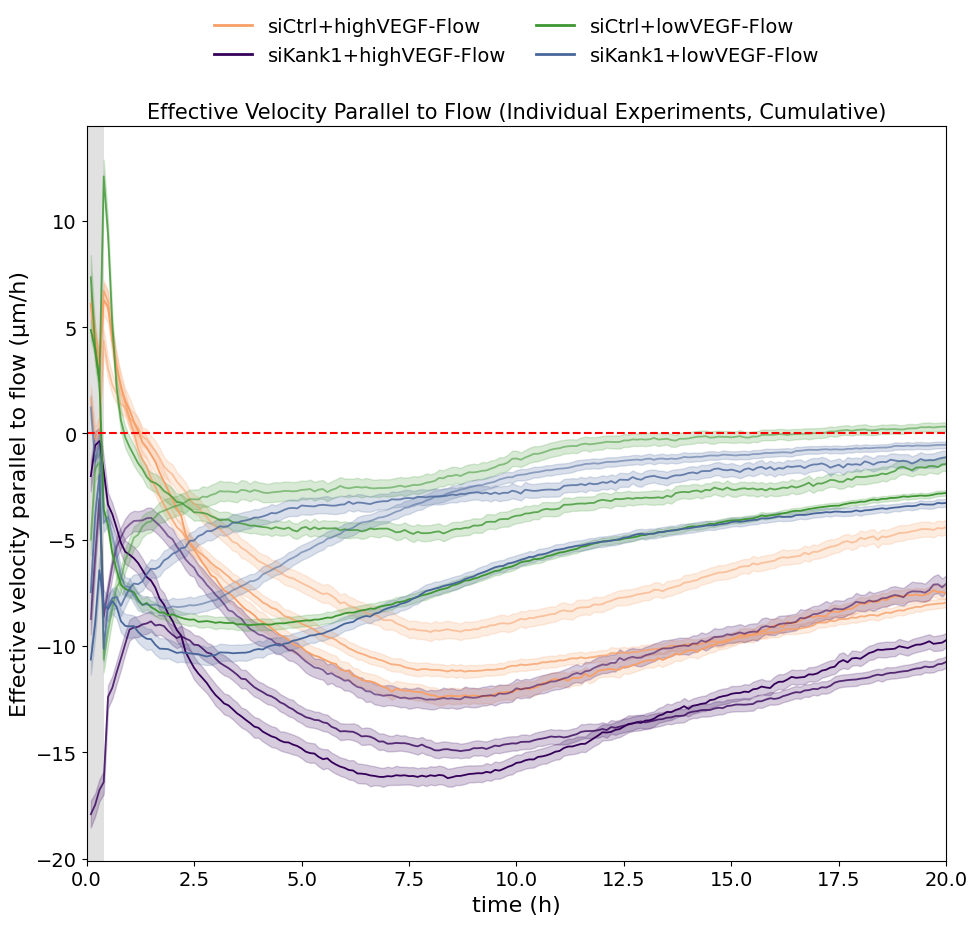

In [21]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',     # default modern sans serif
})

# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["eff_vel_x_mu_per_h"])
#plot_migration_speeds = migration_speed_df.dropna()
#plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)

print("plot_migration_speeds", plot_migration_speeds.shape)
fig, ax = plt.subplots(1, figsize=(10,10))

for t in present_treatments:
    # boolean mask avoids building a big grouped copy
    m_t = (plot_migration_speeds["treatment"].values == t)

    # stable order of filenames within this treatment
    files_t = pd.unique(plot_migration_speeds.loc[m_t, "filename"])

    for i, fname in enumerate(files_t):
        a = alpha_cycle[i % len(alpha_cycle)]
        m_tf = m_t & (plot_migration_speeds["filename"].values == fname)

        # slice ONLY the columns needed for plotting to minimize memory
        df_f = plot_migration_speeds.loc[m_tf, ["time_in_h", "eff_vel_x_mu_per_h", "treatment", "filename"]]


        sns.lineplot(x = "time_in_h",
                    y = "eff_vel_x_mu_per_h",
                    hue = "treatment", hue_order = treatment_order, 
                    data = df_f, 
                    style="filename",
                    dashes=False,
                    legend=False,   # suppress the built-in mixed legend
                    lw=1.3, alpha=a,
                    ax=ax, errorbar=('ci', 95), palette=color_palette 
                    ) 

# labels & ticks
ax.set_ylabel("Effective velocity parallel to flow (µm/h)", fontsize=16)
ax.set_xlabel("time (h)", fontsize=16)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2.5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# title & axes decorations
ax.set_title("Effective Velocity Parallel to Flow (Individual Experiments, Cumulative)", fontsize=15)
ax.set_xlim(0, 20.0)
ax.axhline(y=0.0, color='r', linestyle='dashed')
# Draw pre-flow band (optional)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

# --- custom legend: treatments only, above x-axis ---
handles = [Line2D([0],[0], color=color_palette[t], lw=2, label=t) for t in treatment_order]

ncols = 2                                   # two entries per row
nrows = int(np.ceil(len(treatment_order)/ncols))
y_offset = -0.22 - 0.05*(nrows - 1)         # push further down for extra rows

ax.legend(handles=handles, title=None,
          loc="lower center", bbox_to_anchor=(0.5, 1.01 + 0.05 * (nrows - 1)),  # bump up if multiple rows,
          ncol=ncols, frameon=False, columnspacing=1.5, handletextpad=0.8)

# leave extra bottom margin for the legend (grow with rows)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave some room at top for legend
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.savefig(str(output_folder.joinpath(subfolder, "eff_speed_cumulative_parallel_individual_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "eff_speed_cumulative_parallel_individual_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".png")))

Effective Velocity Parallel to flow (New, pooled experiments, cumulative)

plot_migration_speeds (25152069, 31)


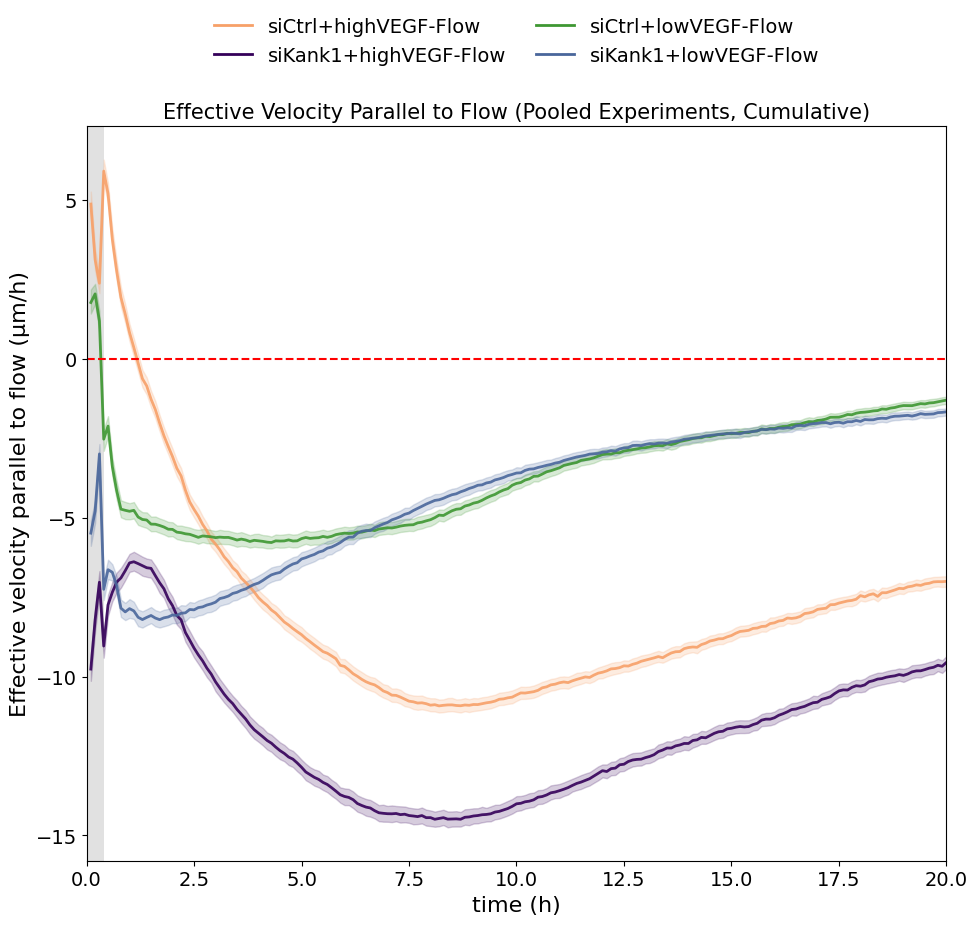

In [22]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',     # default modern sans serif
})

# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["eff_vel_x_mu_per_h"])
#plot_migration_speeds = migration_speed_df.dropna()
#plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)

print("plot_migration_speeds", plot_migration_speeds.shape)
fig, ax = plt.subplots(1, figsize=(10,10))

present_treatments = [t for t in treatment_order
                      if (plot_migration_speeds["treatment"] == t).any()]

for t in present_treatments:
    # filter (small slice) **per treatment**, not per filename
    m_t  = (plot_migration_speeds["treatment"].values == t)
    df_t = plot_migration_speeds.loc[m_t, ["time_in_h", "eff_vel_x_mu_per_h", "treatment"]]

    sns.lineplot(
        data=df_t,
        x="time_in_h", y="eff_vel_x_mu_per_h",
        hue="treatment", hue_order=treatment_order, palette=color_palette,
        errorbar=("ci", 95),         # 95% CI across those observations
        lw=2, alpha=0.9,
        legend=False, ax=ax
    )


# labels & ticks
ax.set_ylabel("Effective velocity parallel to flow (µm/h)", fontsize=16)
ax.set_xlabel("time (h)", fontsize=16)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2.5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# title & axes decorations
ax.set_title("Effective Velocity Parallel to Flow (Pooled Experiments, Cumulative)", fontsize=15)
ax.set_xlim(0, 20.0)
ax.axhline(y=0.0, color='r', linestyle='dashed')
# Draw pre-flow band (optional)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

# --- custom legend: treatments only, above x-axis ---
handles = [Line2D([0],[0], color=color_palette[t], lw=2, label=t) for t in treatment_order]

ncols = 2                                   # two entries per row
nrows = int(np.ceil(len(treatment_order)/ncols))
y_offset = -0.22 - 0.05*(nrows - 1)         # push further down for extra rows

ax.legend(handles=handles, title=None,
          loc="lower center", bbox_to_anchor=(0.5, 1.01 + 0.05 * (nrows - 1)),  # bump up if multiple rows,
          ncol=ncols, frameon=False, columnspacing=1.5, handletextpad=0.8)

# leave extra bottom margin for the legend (grow with rows)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave some room at top for legend
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.savefig(str(output_folder.joinpath(subfolder, "eff_speed_cumulative_parallel_pooled_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "eff_speed_cumulative_parallel_pooled_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".png")))

Effective velocity parallel to flow (Old version, different legend, individual experiments)

In [ ]:
plt.rcParams.update({'font.size': 14})

plot_eff = migration_speed_df.dropna(subset=["eff_vel_x_mu_per_h"])
print("plot_eff (parallel) shape:", plot_eff.shape)

fig, ax = plt.subplots(1, figsize=(10,10))

sns.lineplot(
    x="time_in_h", y="eff_vel_x_mu_per_h",
    hue="treatment", hue_order=treatment_order,
    style="filename", data=plot_eff,
    errorbar=('ci', 95), palette=color_palette, ax=ax
)

ax.set_ylabel("effective velocity ∥ flow (μm/h)")
ax.set_xlabel("time (h)")
ax.set_title("Effective velocity parallel to flow (all individual experiments)")
ax.axhline(y=0.0, color='r', linestyle='dashed')
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig(str(output_folder.joinpath(subfolder, f"eff_v_parallel_individual_exps_timelag_{interval}.pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, f"eff_v_parallel_individual_exps_timelag_{interval}.png")))


Effective velocity total (cumulative,individual experiments)

In [ ]:
plt.rcParams.update({'font.size': 14})

plot_eff_tot = migration_speed_df.dropna(subset=["eff_vel_mu_per_h"])
print("plot_eff (total) shape:", plot_eff_tot.shape)

fig, ax = plt.subplots(1, figsize=(16,8))
sns.lineplot(
    x="time_in_h", y="eff_vel_mu_per_h",
    hue="treatment", hue_order=treatment_order,
    style="filename", data=plot_eff_tot,
    errorbar=('ci', 95), palette=color_palette, ax=ax
)

ax.set_ylabel("effective velocity (μm/h)")
ax.set_xlabel("time (h)")
ax.set_title("Effective velocity (total, all individual experiments)")
# (no zero-line needed; total is non-negative)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig(str(output_folder.joinpath(subfolder, f"eff_v_total_individual_exps_timelag_{interval}.pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, f"eff_v_total_individual_exps_timelag_{interval}.png")))


Total Effective Velocity (individual experiment, rolling 1-hour window)

In [ ]:
plt.rcParams.update({'font.size': 14})

plot_eff_1h = migration_speed_df.dropna(subset=["eff_vel_1h_mu_per_h"])
print("plot_eff_1h shape:", plot_eff_1h.shape)

fig, ax = plt.subplots(1, figsize=(16,8))


sns.lineplot(
    x="time_in_h", y="eff_vel_1h_mu_per_h",
    hue="treatment", hue_order=treatment_order,
    style="filename",
    data=plot_eff_1h,
    errorbar=('ci', 95), palette=color_palette, ax=ax
)

ax.set_ylabel("effective speed (1h window, μm/h)")
ax.set_xlabel("time (h)")
ax.set_title("Effective speed over last 1h (all individual experiments)")
# magnitude ≥ 0
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig(str(output_folder.joinpath(subfolder, f"eff_speed_1h_individual_exps_timelag_{interval}.pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, f"eff_speed_1h_individual_exps_timelag_{interval}.png")))


# Directionality/Persistence


Directionality ratio 𝑑/𝐷 (Old version, different legend and too many filenames in legend, cumulative,individual experiments)

In [ ]:
plt.rcParams.update({'font.size': 14})

plot_dir = migration_speed_df.dropna(subset=["dir_ratio"])
print("plot_dir_ratio shape:", plot_dir.shape)

fig, ax = plt.subplots(1, figsize=(16,8))


sns.lineplot(
    x="time_in_h", y="dir_ratio",
    hue="treatment", hue_order=treatment_order,
    style="filename", data=plot_dir,
    errorbar=('ci', 95), palette=color_palette, ax=ax
)

ax.set_ylabel("directionality ratio d/D")
ax.set_xlabel("time (h)")
ax.set_title("Directionality ratio over time (cumulative, all individual experiments)")
ax.set_ylim(0, 1.05)
ax.axhline(y=1.0, color='r', linestyle='dashed')  # straight-line reference
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig(str(output_folder.joinpath(subfolder, f"dir_ratio_individual_exps_timelag_{interval}.pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, f"dir_ratio_individual_exps_timelag_{interval}.png")))


Directionality ratio 𝑑/𝐷 (New version, cumulative, individual experiments)

plot_migration_speeds (25142248, 31)


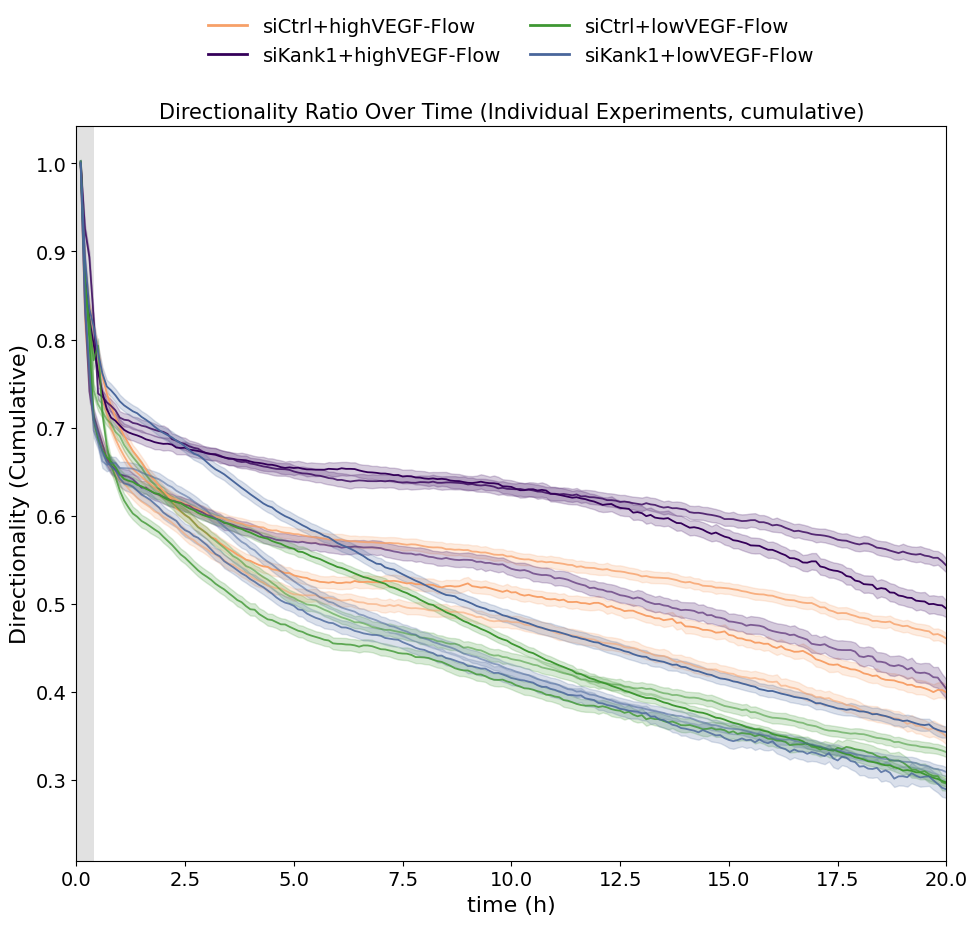

In [23]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',     # default modern sans serif
})

# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["dir_ratio"])
#plot_migration_speeds = migration_speed_df.dropna()
#plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)

print("plot_migration_speeds", plot_migration_speeds.shape)
fig, ax = plt.subplots(1, figsize=(10,10))

for t in present_treatments:
    # boolean mask avoids building a big grouped copy
    m_t = (plot_migration_speeds["treatment"].values == t)

    # stable order of filenames within this treatment
    files_t = pd.unique(plot_migration_speeds.loc[m_t, "filename"])

    for i, fname in enumerate(files_t):
        a = alpha_cycle[i % len(alpha_cycle)]
        m_tf = m_t & (plot_migration_speeds["filename"].values == fname)

        # slice ONLY the columns needed for plotting to minimize memory
        df_f = plot_migration_speeds.loc[m_tf, ["time_in_h", "dir_ratio", "treatment", "filename"]]


        sns.lineplot(x = "time_in_h",
                    y = "dir_ratio",
                    hue = "treatment", hue_order = treatment_order, 
                    data = df_f, 
                    style="filename",
                    dashes=False,
                    legend=False,   # suppress the built-in mixed legend
                    lw=1.3, alpha=a,
                    ax=ax, errorbar=('ci', 95), palette=color_palette 
                    ) 

# labels & ticks
ax.set_ylabel("Directionality (Cumulative)", fontsize=16)
ax.set_xlabel("time (h)", fontsize=16)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2.5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# title & axes decorations
ax.set_title("Directionality Ratio Over Time (Individual Experiments, cumulative)", fontsize=15)
ax.set_xlim(0, 20.0)
# Draw pre-flow band (optional)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

# --- custom legend: treatments only, above x-axis ---
handles = [Line2D([0],[0], color=color_palette[t], lw=2, label=t) for t in treatment_order]

ncols = 2                                   # two entries per row
nrows = int(np.ceil(len(treatment_order)/ncols))
y_offset = -0.22 - 0.05*(nrows - 1)         # push further down for extra rows

ax.legend(handles=handles, title=None,
          loc="lower center", bbox_to_anchor=(0.5, 1.01 + 0.05 * (nrows - 1)),  # bump up if multiple rows,
          ncol=ncols, frameon=False, columnspacing=1.5, handletextpad=0.8)

# leave extra bottom margin for the legend (grow with rows)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave some room at top for legend
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.savefig(str(output_folder.joinpath(subfolder, "dir_ratio_individual_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "dir_ratio_individual_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h" + ".png")))

Directionality ratio 𝑑/𝐷 (New version, cumulative, pooled experiments)

plot_migration_speeds (25142248, 31)


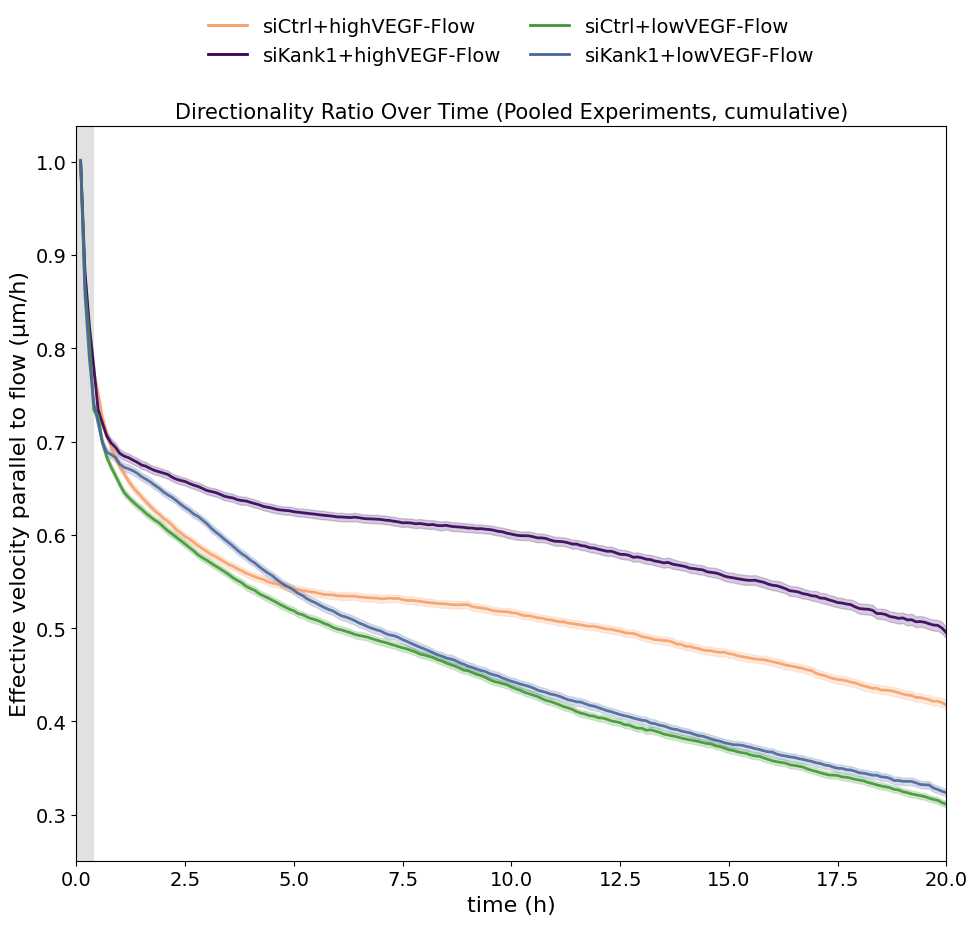

In [24]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',     # default modern sans serif
})

# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["dir_ratio"])
#plot_migration_speeds = migration_speed_df.dropna()
#plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)

print("plot_migration_speeds", plot_migration_speeds.shape)
fig, ax = plt.subplots(1, figsize=(10,10))

present_treatments = [t for t in treatment_order
                      if (plot_migration_speeds["treatment"] == t).any()]

for t in present_treatments:
    # filter (small slice) **per treatment**, not per filename
    m_t  = (plot_migration_speeds["treatment"].values == t)
    df_t = plot_migration_speeds.loc[m_t, ["time_in_h", "dir_ratio", "treatment"]]

    sns.lineplot(
        data=df_t,
        x="time_in_h", y="dir_ratio",
        hue="treatment", hue_order=treatment_order, palette=color_palette,
        errorbar=("ci", 95),         # 95% CI across those observations
        lw=2, alpha=0.9,
        legend=False, ax=ax
    )


# labels & ticks
ax.set_ylabel("Effective velocity parallel to flow (µm/h)", fontsize=16)
ax.set_xlabel("time (h)", fontsize=16)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2.5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# title & axes decorations
ax.set_title("Directionality Ratio Over Time (Pooled Experiments, cumulative)", fontsize=15)
ax.set_xlim(0, 20.0)
# Draw pre-flow band (optional)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

# --- custom legend: treatments only, above x-axis ---
handles = [Line2D([0],[0], color=color_palette[t], lw=2, label=t) for t in treatment_order]

ncols = 2                                   # two entries per row
nrows = int(np.ceil(len(treatment_order)/ncols))
y_offset = -0.22 - 0.05*(nrows - 1)         # push further down for extra rows

ax.legend(handles=handles, title=None,
          loc="lower center", bbox_to_anchor=(0.5, 1.01 + 0.05 * (nrows - 1)),  # bump up if multiple rows,
          ncol=ncols, frameon=False, columnspacing=1.5, handletextpad=0.8)

# leave extra bottom margin for the legend (grow with rows)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave some room at top for legend
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.savefig(str(output_folder.joinpath(subfolder, "dir_ratio_pooled_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h.pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "dir_ratio_pooled_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h.png")))

Persistence(Old version, rolling 1-hour window, individual experiments)

In [ ]:
plt.rcParams.update({'font.size': 14})

plot_pers_1h = migration_speed_df.dropna(subset=["dir_ratio_1h"])
print("plot_pers_1h shape:", plot_pers_1h.shape)

fig, ax = plt.subplots(1, figsize=(16,8))
color_palette = {"siGENOMEsiKank1+lowVEGF-Flow": "limegreen",
                 "siCtrl+highVEGF-Stat": "violet",
                 "siCtrl+highVEGF-Flow": "red"}

sns.lineplot(
    x="time_in_h", y="dir_ratio_1h",
    hue="treatment", hue_order=treatment_order,
    style="filename",
    data=plot_pers_1h, errorbar=('ci', 95),
    palette=color_palette, ax=ax
)

ax.set_ylabel("persistence (effective/total in 1h)")
ax.set_xlabel("time (h)")
ax.set_title("Persistence over last 1h (all individual experiments)")
ax.set_ylim(0, 1.05)
ax.axhline(y=1.0, color='r', linestyle='dashed')  # straight-line reference
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig(str(output_folder.joinpath(subfolder, f"persistence_1h_individual_exps_timelag_{interval}.pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, f"persistence_1h_individual_exps_timelag_{interval}.png")))


Persistence (New version, rolling 1-hour window, individual experiments)

plot_migration_speeds (24222318, 31)


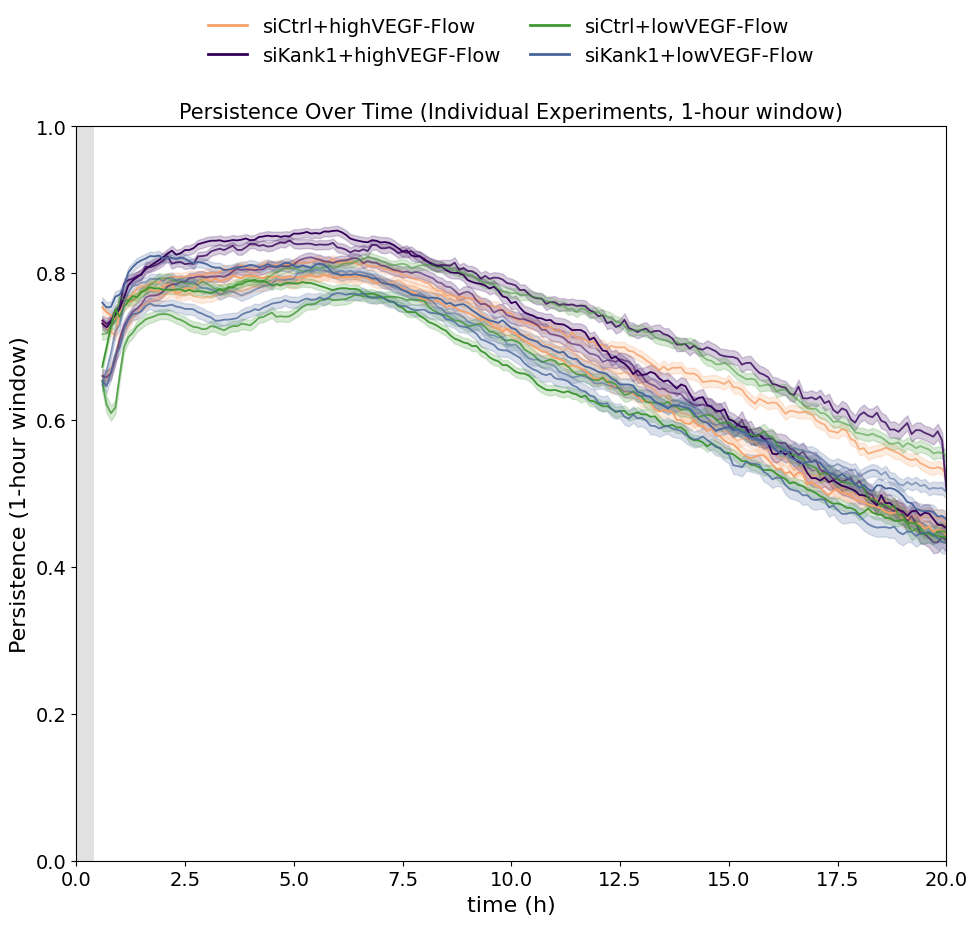

In [25]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',     # default modern sans serif
})

# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["dir_ratio_1h"])
#plot_migration_speeds = migration_speed_df.dropna()
#plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)

print("plot_migration_speeds", plot_migration_speeds.shape)
fig, ax = plt.subplots(1, figsize=(10,10))

for t in present_treatments:
    # boolean mask avoids building a big grouped copy
    m_t = (plot_migration_speeds["treatment"].values == t)

    # stable order of filenames within this treatment
    files_t = pd.unique(plot_migration_speeds.loc[m_t, "filename"])

    for i, fname in enumerate(files_t):
        a = alpha_cycle[i % len(alpha_cycle)]
        m_tf = m_t & (plot_migration_speeds["filename"].values == fname)

        # slice ONLY the columns needed for plotting to minimize memory
        df_f = plot_migration_speeds.loc[m_tf, ["time_in_h", "dir_ratio_1h", "treatment", "filename"]]


        sns.lineplot(x = "time_in_h",
                    y = "dir_ratio_1h",
                    hue = "treatment", hue_order = treatment_order, 
                    data = df_f, 
                    style="filename",
                    dashes=False,
                    legend=False,   # suppress the built-in mixed legend
                    lw=1.3, alpha=a,
                    ax=ax, errorbar=('ci', 95), palette=color_palette 
                    ) 

# labels & ticks
ax.set_ylabel("Persistence (1-hour window)", fontsize=16)
ax.set_xlabel("time (h)", fontsize=16)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2.5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# title & axes decorations
ax.set_title("Persistence Over Time (Individual Experiments, 1-hour window)", fontsize=15)
ax.set_xlim(0, 20.0)
ax.set_ylim(0, 1.0)        
# Draw pre-flow band (optional)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

# --- custom legend: treatments only, above x-axis ---
handles = [Line2D([0],[0], color=color_palette[t], lw=2, label=t) for t in treatment_order]

ncols = 2                                   # two entries per row
nrows = int(np.ceil(len(treatment_order)/ncols))
y_offset = -0.22 - 0.05*(nrows - 1)         # push further down for extra rows

ax.legend(handles=handles, title=None,
          loc="lower center", bbox_to_anchor=(0.5, 1.01 + 0.05 * (nrows - 1)),  # bump up if multiple rows,
          ncol=ncols, frameon=False, columnspacing=1.5, handletextpad=0.8)

# leave extra bottom margin for the legend (grow with rows)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave some room at top for legend
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.savefig(str(output_folder.joinpath(subfolder, "dir_ratio_1h_individual_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h.pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "dir_ratio_1h_individual_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h.png")))

Persistence  (New version, 1-hour window, pooled experiments)

plot_migration_speeds (24222318, 31)


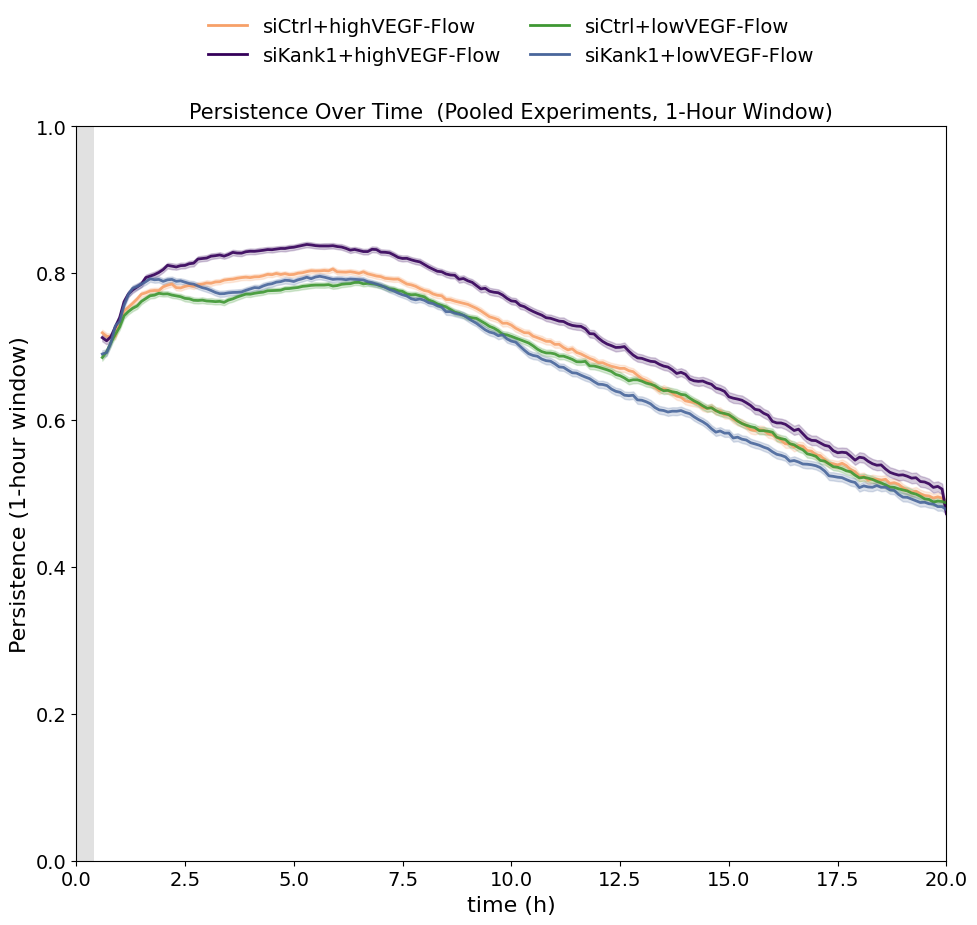

In [26]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',     # default modern sans serif
})

# Keep only rows that have a computable velocity; don't blanket-drop all NaNs
plot_migration_speeds = migration_speed_df.dropna(subset=["dir_ratio_1h"])
#plot_migration_speeds = migration_speed_df.dropna()
#plot_migration_speeds = plot_migration_speeds.iloc[::subsample_n, :]
#plot_migration_speeds = plot_migration_speeds.sample(frac=subsample_frac, replace=True, random_state=1)

print("plot_migration_speeds", plot_migration_speeds.shape)
fig, ax = plt.subplots(1, figsize=(10,10))

present_treatments = [t for t in treatment_order
                      if (plot_migration_speeds["treatment"] == t).any()]

for t in present_treatments:
    # filter (small slice) **per treatment**, not per filename
    m_t  = (plot_migration_speeds["treatment"].values == t)
    df_t = plot_migration_speeds.loc[m_t, ["time_in_h", "dir_ratio_1h", "treatment"]]

    sns.lineplot(
        data=df_t,
        x="time_in_h", y="dir_ratio_1h",
        hue="treatment", hue_order=treatment_order, palette=color_palette,
        errorbar=("ci", 95),         # 95% CI across those observations
        lw=2, alpha=0.9,
        legend=False, ax=ax
    )


# labels & ticks
ax.set_ylabel("Persistence (1-hour window)", fontsize=16)
ax.set_xlabel("time (h)", fontsize=16)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2.5))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# title & axes decorations
ax.set_title("Persistence Over Time  (Pooled Experiments, 1-Hour Window)", fontsize=15)
ax.set_xlim(0, 20.0)
ax.set_ylim(0, 1.0)  
# Draw pre-flow band (optional)
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)

# --- custom legend: treatments only, above x-axis ---
handles = [Line2D([0],[0], color=color_palette[t], lw=2, label=t) for t in treatment_order]

ncols = 2                                   # two entries per row
nrows = int(np.ceil(len(treatment_order)/ncols))
y_offset = -0.22 - 0.05*(nrows - 1)         # push further down for extra rows

ax.legend(handles=handles, title=None,
          loc="lower center", bbox_to_anchor=(0.5, 1.01 + 0.05 * (nrows - 1)),  # bump up if multiple rows,
          ncol=ncols, frameon=False, columnspacing=1.5, handletextpad=0.8)

# leave extra bottom margin for the legend (grow with rows)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave some room at top for legend
if show_pre_flow_band:
    draw_pre_flow_band(ax, pre_flow_frames)
plt.savefig(str(output_folder.joinpath(subfolder, "dir_ratio_1h_pooled_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h.pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, "dir_ratio_1h_pooled_exps_sictrl+sikank1_lowvegf+highvegf_flow_20h.png")))

Direction autocorrelation (individual experiments) - Will work if optional autocorelation spreasheets are generated. As Of Oct 10 2025, not sure if it produces useful info or follows literature method (2024 nat protocols) properly

In [ ]:
# Load per-file direction autocorr summaries
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

ac_dir = output_folder.joinpath("direction_autocorr")
ac_files = sorted(ac_dir.glob("direction_autocorr_*.csv"))
if not ac_files:
    raise FileNotFoundError(f"No autocorr CSVs in {ac_dir}. Run compute_direction_autocorrelation(...) first.")

autocorr_df = pd.concat((pd.read_csv(f) for f in ac_files), ignore_index=True)
# choose which column to plot: unweighted track mean or pairs-weighted mean
ac_col = "ac_mean_tracks"  # or "ac_mean_weighted"
autocorr_df = autocorr_df.dropna(subset=[ac_col, "lag_h"])
print("autocorr_df:", autocorr_df.shape, "files:", len(ac_files))


In [ ]:
fig, ax = plt.subplots(1, figsize=(16,8))
color_palette = {"siGENOMEsiKank1+lowVEGF-Flow": "limegreen",
                 "siCtrl+highVEGF-Stat": "violet",
                 "siCtrl+highVEGF-Flow": "red"}

sns.lineplot(
    x="lag_h", y=ac_col,
    hue="treatment", hue_order=treatment_order,
    style="filename",
    data=autocorr_df,
    errorbar=('ci', 95),
    palette=color_palette, ax=ax
)

ax.set_ylabel("direction autocorrelation (cos Δθ)")
ax.set_xlabel("lag (h)")
ax.set_title("Direction autocorrelation vs lag (individual experiments)")
ax.set_ylim(-1.05, 1.05)
ax.axhline(y=0.0, color='r', linestyle='dashed')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig(str(output_folder.joinpath(subfolder, f"dir_autocorr_individual_exps_timelag_{interval}.pdf")))
plt.savefig(str(output_folder.joinpath(subfolder, f"dir_autocorr_individual_exps_timelag_{interval}.png")))


In [ ]:
single_time_point = plot_migration_speeds[plot_migration_speeds["FRAME"]==24]
#single_time_point.groupby(["filename","condition"])["vel_x"].mean()

display(single_time_point)
plot_data = single_time_point.groupby(["treatment", "filename"])["vel_x_mu_per_h"].mean().reset_index()
display(plot_data)

# Box Plots for single time points & time intervals

Velocity Box plot for single time points (Non-granular box plot, taking average of entire experiments)

In [ ]:

from statannot import add_stat_annotation

fig, ax = plt.subplots(1, figsize=(10,10))

plt.rcParams.update({'font.size': 14})

plot_migration_speeds = migration_speed_df.dropna(subset=["vel_x_mu_per_h"])
single_time_point = plot_migration_speeds[plot_migration_speeds["FRAME"]==24]
plot_data = single_time_point.groupby(["treatment", "filename"])["vel_x_mu_per_h"].mean().reset_index()
#plot_data = single_time_point.copy()

sns.boxplot(data = plot_data, x = "treatment", order = treatment_order, y = "vel_x_mu_per_h" )
sns.swarmplot(data = plot_data, x = "treatment", order = treatment_order, y = "vel_x_mu_per_h" , color="black", size =10)
test_results = add_stat_annotation(ax, data=plot_data, y = "vel_x_mu_per_h", x = "treatment", order=treatment_order, 
                                   #order=order,
                                   #box_pairs=[("siCtrl+highVEGF-Flow", "siCtrl+highVEGF-Stat")],
                                   test='t-test_welch', 
                                   #text_format='full',
                                   #text_format='star',
                                   text_format='simple',
                                   loc='inside', verbose=2)

ax.set_ylabel("velocity against flow in microns/h")
ax.set_title("velocity against flow after 2h")
ax.set_ylim(-7.5,0.5)


plt.savefig("velocity_against_flow_box_plot.png")
plt.savefig("velocity_against_flow_box_plot.pdf")
#plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
#plt.legend(loc=2, borderaxespad=0.)

Velocity Box plot for single time points (Granular box plot, demonstrating per track values(can be toggled to take % of data and overlay as dots))

In [ ]:
import matplotlib
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

# Replicate colors/shapes — Rep1 = cyan, Rep2 = orange, Rep3 = grey
REPL_COL = {
    1: "#56B4E9",  # cyan
    2: "#E69F00",  # orange
    3: "#7A7A7A",  # grey
    4: "#CC79A7",  # magenta reserve
    5: "#009E73",  # teal reserve
}
REPL_MRK = {
    1: "s",  # square
    2: "o",  # circle
    3: "^",  # triangle
    4: "D",  # diamond (reserve)
    5: "P",  # filled plus (reserve)
}
PALETTE = [REPL_COL[idx] for idx in sorted(REPL_COL)]
REPLICATE_MARKERS = [REPL_MRK[idx] for idx in sorted(REPL_MRK)]

# Granular scatter tuning
SCATTER_SUBSAMPLE_FRAC = 0.50  # 50% of the 10% subsample
SCATTER_JITTER_WIDTH = 0.2
SCATTER_MIN_SEP = 0.014
SCATTER_MARKER_SIZE = 38
SCATTER_JITTER_ATTEMPTS = 400

fig, ax = plt.subplots(1, figsize=(10, 10))

plt.rcParams.update({'font.size': 14})

plot_migration_speeds = migration_speed_df.dropna(subset=["vel_x_mu_per_h"])
plot_migration_speeds = plot_migration_speeds.iloc[::10, :]

single_time_point = plot_migration_speeds[plot_migration_speeds["FRAME"] == 24]
plot_data = single_time_point.copy()

# Merge replicate metadata (date/experiment day) for superplot styling
replicate_lookup = key_selection[['experimentID', 'date']].drop_duplicates()
plot_data = plot_data.merge(replicate_lookup, on="experimentID", how="left")
plot_data["replicate_label"] = plot_data["date"].fillna(plot_data["experimentID"]).astype(str)

# Keep only treatments present in the requested order
treatment_positions = {t: i for i, t in enumerate(treatment_order)}
plot_data = plot_data[plot_data["treatment"].isin(treatment_positions)]
plot_data = plot_data.copy()

if plot_data.empty:
    raise ValueError("No data available for the selected treatments at frame 24.")

# Prepare replicate-specific colors and markers
replicate_info = (
    plot_data[['replicate_label', 'date']].drop_duplicates()
    .assign(date_parsed=lambda df: pd.to_datetime(df['date'], dayfirst=True, errors='coerce'))
    .sort_values(['date_parsed', 'replicate_label'])
)
replicate_order = replicate_info['replicate_label'].tolist()
if not replicate_order:
    replicate_order = sorted(plot_data['replicate_label'].unique())
replicate_indices = {rep: idx + 1 for idx, rep in enumerate(replicate_order)}
fallback_colors = sns.color_palette("husl", max(6, len(replicate_order) + 2))
fallback_markers = ["X", "P", "D", "*", "v", "<", ">", "H"]
replicate_colors = {}
replicate_markers = {}
for rep in replicate_order:
    idx = replicate_indices[rep]
    color = REPL_COL.get(idx)
    marker = REPL_MRK.get(idx)
    if color is None:
        color = fallback_colors[(idx - 1) % len(fallback_colors)]
    if marker is None:
        marker = fallback_markers[(idx - 1) % len(fallback_markers)]
    replicate_colors[rep] = color
    replicate_markers[rep] = marker

# Violin plot (most transparent layer)
treatment_palette = {
    "siCtrl+highVEGF-Stat": "violet",
    "siCtrl+highVEGF-Flow": "red",
    "siGENOMEsiKank1+lowVEGF-Flow": "limegreen",
}
fallback_palette = sns.color_palette("deep", n_colors=len(treatment_order))
for idx, treatment in enumerate(treatment_order):
    treatment_palette.setdefault(treatment, fallback_palette[idx % len(fallback_palette)])

sns.violinplot(
    data=plot_data,
    x="treatment",
    y="vel_x_mu_per_h",
    order=treatment_order,
    palette=treatment_palette,
    cut=0,
    inner=None,
    linewidth=1.2,
    ax=ax,
 )

# Make violin interiors transparent with black outlines
violin_collections = [c for c in ax.collections if isinstance(c, matplotlib.collections.PolyCollection)]
for idx, collection in enumerate(violin_collections[:len(treatment_order)]):
    collection.set_facecolor(mcolors.to_rgba("black", alpha=0.0))
    collection.set_edgecolor(mcolors.to_rgba("black", alpha=1.0))
    collection.set_linewidth(1.3)

# Prepare replicate means
plot_data = plot_data.assign(
    x_pos=plot_data["treatment"].map(treatment_positions).astype(float),
)

# Subsample scatter data (25% of the 10% subsample)
sampling_rng = np.random.default_rng(2025)

def _subsample_group(df, rng, frac):
    if df.empty:
        return df
    n_rows = max(1, int(np.ceil(len(df) * frac)))
    seed = int(rng.integers(0, 1_000_000_000))
    return df.sample(n=n_rows, replace=False, random_state=seed)

scatter_data = (
    plot_data.groupby(['treatment', 'replicate_label'], group_keys=False)
    .apply(lambda grp: _subsample_group(grp, sampling_rng, SCATTER_SUBSAMPLE_FRAC))
    .reset_index(drop=True)
)

scatter_data = scatter_data.copy()
scatter_data['x_pos'] = scatter_data['treatment'].map(treatment_positions).astype(float)
scatter_data['x_jitter'] = scatter_data['x_pos']

# Assign jitter positions while avoiding overlapping markers
jitter_rng = np.random.default_rng(321)
for treatment, idx_values in scatter_data.groupby('treatment').groups.items():
    sorted_idx = (
        scatter_data.loc[idx_values]
        .sort_values('vel_x_mu_per_h')
        .index
    )
    base_pos = treatment_positions[treatment]
    offsets = []
    for row_idx in sorted_idx:
        local_width = SCATTER_JITTER_WIDTH
        local_min_sep = SCATTER_MIN_SEP
        placed = False
        for attempt in range(SCATTER_JITTER_ATTEMPTS):
            candidate = base_pos + jitter_rng.uniform(-local_width, local_width)
            if all(abs(candidate - existing) >= local_min_sep for existing in offsets):
                offsets.append(candidate)
                placed = True
                break
            if (attempt + 1) % 80 == 0:
                local_min_sep *= 0.9
                local_width *= 1.05
        if not placed:
            offsets.append(base_pos + jitter_rng.uniform(-SCATTER_JITTER_WIDTH, SCATTER_JITTER_WIDTH))
    scatter_data.loc[sorted_idx, 'x_jitter'] = offsets

# Scatter per-track values with transparent faces and colored outlines
for replicate in replicate_order:
    subset = scatter_data[scatter_data["replicate_label"] == replicate]
    if subset.empty:
        continue
    color = replicate_colors[replicate]
    marker = replicate_markers[replicate]
    ax.scatter(
        subset["x_jitter"],
        subset["vel_x_mu_per_h"],
        marker=marker,
        s=SCATTER_MARKER_SIZE,
        facecolors="none",
        edgecolors=mcolors.to_rgba(color, alpha=0.85),
        linewidth=0.9,
        zorder=3,
    )

# Overlay replicate means (least transparent, larger markers)
replicate_means = (
    plot_data.groupby(["treatment", "replicate_label"], as_index=False)["vel_x_mu_per_h"].mean()
)
replicate_means["x_pos"] = replicate_means["treatment"].map(treatment_positions).astype(float)
for _, row in replicate_means.iterrows():
    color = replicate_colors[row["replicate_label"]]
    marker = replicate_markers[row["replicate_label"]]
    ax.scatter(
        row["x_pos"],
        row["vel_x_mu_per_h"],
        marker=marker,
        s=140,
        color=mcolors.to_rgba(color, alpha=0.95),
        edgecolor="black",
        linewidth=0.9,
        zorder=4,
    )

# Statistical annotation on granular data
test_results = add_stat_annotation(
    ax,
    data=plot_data,
    y="vel_x_mu_per_h",
    x="treatment",
    order=treatment_order,
    box_pairs=[("siCtrl+highVEGF-Flow", "siCtrl+highVEGF-Stat")],
    test='t-test_welch',
    text_format='simple',
    loc='inside',
    verbose=2,
 )

ax.set_ylabel("velocity against flow in microns/h")
ax.set_title("velocity against flow after 2h")

# Custom legend for biological replicates
legend_handles = [
    Line2D(
        [0],
        [0],
        marker=replicate_markers[rep],
        color='w',
        markerfacecolor='none',
        markeredgecolor=mcolors.to_rgba(replicate_colors[rep], alpha=0.85),
        markeredgewidth=1.0,
        markersize=8,
        linestyle='None',
        label=rep,
    )
    for rep in replicate_order
]
ax.legend(
    handles=legend_handles,
    title="Experiment date",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
 )

plt.savefig("velocity_against_flow_box_plot_granular.png")
plt.savefig("velocity_against_flow_box_plot_granular.pdf")

Velocity Box plot for single time points (Granular box plot, demonstrating per track values(can be toggled to take % of data and overlay as dots)), sns.swarmplot version

In [ ]:
# Swarmplot-based superplot variant
SWARM_SUBSAMPLE_FRAC = 0.75  # 75% of the 10% subsample
SWARM_MARKER_SIZE = 4.2
SWARM_MEAN_SIZE = 145
SWARM_EDGEWIDTH = 0.9

fig, ax = plt.subplots(1, figsize=(10, 10))

plt.rcParams.update({'font.size': 14})

plot_migration_speeds = migration_speed_df.dropna(subset=["vel_x_mu_per_h"])
plot_migration_speeds = plot_migration_speeds.iloc[::10, :]

single_time_point = plot_migration_speeds[plot_migration_speeds["FRAME"] == 24]
plot_data = single_time_point.copy()

# Merge replicate metadata (date/experiment day) for superplot styling
replicate_lookup = key_selection[['experimentID', 'date']].drop_duplicates()
plot_data = plot_data.merge(replicate_lookup, on="experimentID", how="left")
plot_data["replicate_label"] = plot_data["date"].fillna(plot_data["experimentID"]).astype(str)

# Keep only treatments present in the requested order
treatment_positions = {t: i for i, t in enumerate(treatment_order)}
plot_data = plot_data[plot_data["treatment"].isin(treatment_positions)]
plot_data = plot_data.copy()

if plot_data.empty:
    raise ValueError("No data available for the selected treatments at frame 24.")

# Prepare replicate-specific colors and markers
replicate_info = (
    plot_data[['replicate_label', 'date']].drop_duplicates()
    .assign(date_parsed=lambda df: pd.to_datetime(df['date'], dayfirst=True, errors='coerce'))
    .sort_values(['date_parsed', 'replicate_label'])
)
replicate_order = replicate_info['replicate_label'].tolist()
if not replicate_order:
    replicate_order = sorted(plot_data['replicate_label'].unique())
replicate_indices = {rep: idx + 1 for idx, rep in enumerate(replicate_order)}
fallback_colors = sns.color_palette("husl", max(6, len(replicate_order) + 2))
fallback_markers = ["X", "P", "D", "*", "v", "<", ">", "H"]
replicate_colors = {}
replicate_markers = {}
for rep in replicate_order:
    idx = replicate_indices[rep]
    color = REPL_COL.get(idx)
    marker = REPL_MRK.get(idx)
    if color is None:
        color = fallback_colors[(idx - 1) % len(fallback_colors)]
    if marker is None:
        marker = fallback_markers[(idx - 1) % len(fallback_markers)]
    replicate_colors[rep] = color
    replicate_markers[rep] = marker

# Violin background as contextual density layer
treatment_palette = {
    "siCtrl+highVEGF-Stat": "violet",
    "siCtrl+highVEGF-Flow": "red",
    "siGENOMEsiKank1+lowVEGF-Flow": "limegreen",
}
fallback_palette = sns.color_palette("deep", n_colors=len(treatment_order))
for idx, treatment in enumerate(treatment_order):
    treatment_palette.setdefault(treatment, fallback_palette[idx % len(fallback_palette)])

sns.violinplot(
    data=plot_data,
    x="treatment",
    y="vel_x_mu_per_h",
    order=treatment_order,
    palette=treatment_palette,
    cut=0,
    inner=None,
    linewidth=1.2,
    ax=ax,
 )

violin_collections = [c for c in ax.collections if isinstance(c, matplotlib.collections.PolyCollection)]
for idx, collection in enumerate(violin_collections[:len(treatment_order)]):
    collection.set_facecolor(mcolors.to_rgba("black", alpha=0.0))
    collection.set_edgecolor(mcolors.to_rgba("black", alpha=1.0))
    collection.set_linewidth(1.3)

plot_data = plot_data.assign(
    x_pos=plot_data["treatment"].map(treatment_positions).astype(float),
)

# Subsample scatter data (75% of the 10% subsample)
swarm_rng = np.random.default_rng(2026)

def _swarm_subsample(df, rng, frac):
    if df.empty:
        return df
    n_rows = max(1, int(np.ceil(len(df) * frac)))
    seed = int(rng.integers(0, 1_000_000_000))
    return df.sample(n=n_rows, replace=False, random_state=seed)

swarm_data = (
    plot_data.groupby(['treatment', 'replicate_label'], group_keys=False)
    .apply(lambda grp: _swarm_subsample(grp, swarm_rng, SWARM_SUBSAMPLE_FRAC))
    .reset_index(drop=True)
)

# Draw swarmplot per replicate to enforce individual marker shapes and hollow styling
for rep in replicate_order:
    subset = swarm_data[swarm_data['replicate_label'] == rep]
    if subset.empty:
        continue
    initial_collections = len(ax.collections)
    sns.swarmplot(
        data=subset,
        x="treatment",
        y="vel_x_mu_per_h",
        order=treatment_order,
        color=mcolors.to_rgba(replicate_colors[rep], alpha=0.9),
        marker=replicate_markers[rep],
        size=SWARM_MARKER_SIZE,
        edgecolor=mcolors.to_rgba(replicate_colors[rep], alpha=0.9),
        linewidth=SWARM_EDGEWIDTH,
        dodge=False,
        ax=ax,
    )
    # Hollow out latest collections
    new_collections = ax.collections[initial_collections:]
    for coll in new_collections:
        if isinstance(coll, matplotlib.collections.PathCollection):
            coll.set_facecolor("none")
            coll.set_edgecolor(mcolors.to_rgba(replicate_colors[rep], alpha=0.9))
            coll.set_linewidth(SWARM_EDGEWIDTH)

# Overlay replicate means (solid markers)
replicate_means = (
    plot_data.groupby(["treatment", "replicate_label"], as_index=False)["vel_x_mu_per_h"].mean()
)
replicate_means["x_pos"] = replicate_means["treatment"].map(treatment_positions).astype(float)
for _, row in replicate_means.iterrows():
    color = replicate_colors[row["replicate_label"]]
    marker = replicate_markers[row["replicate_label"]]
    ax.scatter(
        row["x_pos"],
        row["vel_x_mu_per_h"],
        marker=marker,
        s=SWARM_MEAN_SIZE,
        color=mcolors.to_rgba(color, alpha=0.95),
        edgecolor="black",
        linewidth=0.9,
        zorder=4,
    )

# Statistical annotation on granular data (using full 10% subsample)
test_results = add_stat_annotation(
    ax,
    data=plot_data,
    y="vel_x_mu_per_h",
    x="treatment",
    order=treatment_order,
    box_pairs=[("siCtrl+highVEGF-Flow", "siCtrl+highVEGF-Stat")],
    test='t-test_welch',
    text_format='simple',
    loc='inside',
    verbose=2,
 )

ax.set_ylabel("velocity against flow in microns/h")
ax.set_title("velocity against flow after 2h — swarmplot variant")

# Custom legend for biological replicates
legend_handles = [
    Line2D(
        [0],
        [0],
        marker=replicate_markers[rep],
        color='w',
        markerfacecolor='none',
        markeredgecolor=mcolors.to_rgba(replicate_colors[rep], alpha=0.9),
        markeredgewidth=1.0,
        markersize=8,
        linestyle='None',
        label=rep,
    )
    for rep in replicate_order
]
ax.legend(
    handles=legend_handles,
    title="Experiment date",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
 )

plt.savefig("velocity_against_flow_box_plot_granular_swarm.png")
plt.savefig("velocity_against_flow_box_plot_granular_swarm.pdf")

In [ ]:
fig, ax = plt.subplots(1, figsize=(10,10))
plot_migration_speeds = migration_speed_df.dropna(subset=["vel_x_mu_per_h"])
single_time_point = plot_migration_speeds[plot_migration_speeds["FRAME"]==24]

plot_data = single_time_point.groupby(["condition", "filename"])["vel_mu_per_h"].mean().reset_index()

sns.boxplot(data = plot_data, x = "condition", order = treatment_order, y = "vel_mu_per_h" )
sns.swarmplot(data = plot_data, x = "condition", order = treatment_order, y = "vel_mu_per_h" , color="black", size =10)
test_results = add_stat_annotation(ax, data=plot_data, y = "vel_mu_per_h", x = "condition", order = treatment_order, 
                                   #order=order,
                                   box_pairs=[("siCtrl+highVEGF-Flow", "siCtrl+highVEGF-Stat")],
                                   test='t-test_welch', 
                                   #text_format='full',
                                   #text_format='star',
                                   text_format='simple',
                                   loc='inside', verbose=2)


ax.set_ylabel("velocity in microns/h")
ax.set_title("velocity after 2h")
ax.set_ylim(0,14.5)
plt.savefig("velocity_box_plot.png")
plt.savefig("velocity_box_plot.pdf")

In [ ]:
plot_data = single_time_point.groupby(["treatment", "filename"])["vel_mu_per_h"].mean().reset_index()
fig, ax = plt.subplots(1, figsize=(10,10))
sns.boxplot(data = plot_data, x = "treatment", y = "vel_mu_per_h" )
sns.swarmplot(data = plot_data, x = "treatment", y = "vel_mu_per_h" , color="black", size =10)